# **Pronóstico de ocupados en las 13 principales ciudades**

## Evaluación comparativa de modelos de series de tiempo

El presente notebook desarrolla un ejercicio aplicado de pronóstico sobre la variable **Ocupados**, medida en miles de personas para las 13 principales ciudades. Se estiman modelos de tendencia, estacionalidad y combinaciones de ambos componentes, se evalúa el desempeño predictivo mediante un conjunto de entrenamiento y prueba, y se revisan los supuestos de los residuos para seleccionar el modelo más adecuado.

**Integrantes:** Edgar Orlando Ruiz, Martín Naranjo y Sergio Aguilar  
**Universidad:** Pontificia Universidad Javeriana Cali

## **1. Carga de paquetes y librerías**

In [ ]:
# Se instalan o actualizan las librerías requeridas para el análisis.
!pip install -q pandas numpy matplotlib scipy statsmodels scikit-learn openpyxl

In [ ]:
# Se importan las librerías principales para el manejo de datos.
import pandas as pd
import numpy as np

# Se importan librerías para la generación de gráficos.
from matplotlib import pyplot as plt
import pylab as py

# Se importan funciones estadísticas para evaluar los supuestos de los modelos.
from scipy import stats
from statsmodels.sandbox.stats.runs import runstest_1samp  # Prueba de rachas de Wald y Wolfowitz
import statsmodels.api as sm                              # Modelos estadísticos y pruebas de autocorrelación
from statsmodels.stats.stattools import jarque_bera        # Prueba de normalidad Jarque-Bera

# Se importan funciones para medir el error de pronóstico.
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Se importan herramientas para el manejo de fechas.
from datetime import datetime
from dateutil.relativedelta import relativedelta

# Se configura la visualización general de tablas y gráficos.
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.4f}".format)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

# **2. Carga de datos**

En esta sección se carga la base de datos de empleo utilizada en clase. La columna **mes** se define como índice temporal desde la lectura del archivo, lo cual permite trabajar la información como una serie de tiempo mensual. Posteriormente, se revisa la estructura general de la base y se selecciona la variable **Ocupados**, correspondiente al número de ocupados en miles de personas para las 13 principales ciudades.

In [ ]:
url = "https://raw.githubusercontent.com/dagudelo30/Series-de-tiempo---Javeriana-Cali/main/intro-moving_average/datosEmpleo.xlsx"

# Se realiza la lectura de la base de datos definiendo el índice temporal desde el inicio.
# La columna "mes" se utiliza como índice de fechas de la serie.
data = pd.read_excel(url, index_col="mes", parse_dates=True)

# Se visualiza la estructura inicial de la tabla.
data.head()

,TD_13ciudades,Ocupados,Desocupados,Inactivos
mes,,,,
2001-01-01,20.9464,"6,923.6040","1,834.5070","4,600.7180"
2001-02-01,19.8942,"7,037.7460","1,747.8200","4,596.8050"
2001-03-01,19.2216,"6,945.9730","1,652.8230","4,807.1200"
2001-04-01,17.8886,"6,973.0790","1,519.1370","4,937.2800"
2001-05-01,17.9457,"6,994.4620","1,529.7200","4,928.9110"


**Lectura inicial de la base de datos**

La base de datos se cargó correctamente desde el repositorio utilizado en clase, tomando la variable **mes** como índice temporal. La salida inicial muestra que la tabla contiene las variables **TD_13ciudades**, **Ocupados**, **Desocupados** e **Inactivos**, con registros mensuales desde enero de 2001. Para este ejercicio, la variable **Ocupados** será utilizada como serie principal, dado que representa el número de ocupados en miles de personas para las 13 principales ciudades y constituye el objeto del pronóstico a seis meses.

In [ ]:
# Se revisan las dimensiones de la base de datos.
print("Dimensiones de la base de datos:")
print(data.shape)

# Se revisan los nombres de las columnas disponibles.
print("\nColumnas disponibles:")
print(data.columns)

# Se revisan los tipos de datos de cada variable.
print("\nTipos de datos:")
print(data.dtypes)

# Se revisa el rango temporal disponible.
print("\nRango temporal:")
print("Fecha inicial:", data.index.min())
print("Fecha final:", data.index.max())

Dimensiones de la base de datos:
(222, 4)

Columnas disponibles:
Index(['TD_13ciudades', 'Ocupados', 'Desocupados', 'Inactivos'], dtype='object')

Tipos de datos:
TD_13ciudades    float64
Ocupados         float64
Desocupados      float64
Inactivos        float64
dtype: object

Rango temporal:
Fecha inicial: 2001-01-01 00:00:00
Fecha final: 2019-06-01 00:00:00


**Revisión general de la base**

La base contiene **222 registros mensuales** entre **enero de 2001 y junio de 2019**, distribuidos en cuatro variables: **TD_13ciudades**, **Ocupados**, **Desocupados** e **Inactivos**. Todas las columnas son numéricas tipo **float64**, lo cual facilita su uso en los modelos de pronóstico. Esta estructura confirma que la información está organizada como una serie de tiempo mensual y que cuenta con una longitud adecuada para construir conjuntos de entrenamiento y prueba, evaluar diferentes modelos y seleccionar el mejor pronóstico para la variable **Ocupados**.

In [ ]:
# Se verifica si la variable "Ocupados" se encuentra disponible en la base.
if "Ocupados" in data.columns:
    print("La variable 'Ocupados' se encuentra disponible en la base de datos.")
else:
    print("La variable 'Ocupados' no se encuentra con ese nombre exacto.")
    print("Se recomienda revisar los nombres de las columnas disponibles:")
    print(data.columns)

La variable 'Ocupados' se encuentra disponible en la base de datos.


**Validación de la variable de interés**

La salida del código confirma que la variable **Ocupados** está disponible en la base de datos. Esta variable será utilizada como serie principal del análisis, ya que representa el número de personas ocupadas, en miles, para las 13 principales ciudades. A partir de ella se construirán los conjuntos de entrenamiento y prueba, se estimarán los modelos de pronóstico y se seleccionará el mejor resultado para proyectar los próximos seis meses.

In [ ]:
# Se selecciona la variable Ocupados como serie principal del análisis.
# Esta variable representa el número de ocupados en miles de personas.
y = data["Ocupados"]

# Se visualizan las primeras observaciones de la serie seleccionada.
y.head()

,Ocupados
mes,
2001-01-01,"6,923.6040"
2001-02-01,"7,037.7460"
2001-03-01,"6,945.9730"
2001-04-01,"6,973.0790"
2001-05-01,"6,994.4620"


In [ ]:
# Se revisa el número de observaciones disponibles.
print("Número de observaciones de la serie Ocupados:")
print(y.shape[0])

# Se revisa la existencia de valores faltantes.
print("\nNúmero de valores faltantes:")
print(y.isna().sum())

# Se presentan estadísticas descriptivas de la serie.
print("\nEstadísticas descriptivas:")
display(y.describe())

Número de observaciones de la serie Ocupados:
222

Número de valores faltantes:
0

Estadísticas descriptivas:


,Ocupados
count,222.0000
mean,"9,160.8520"
std,"1,295.4928"
min,"6,923.6040"
25%,"7,971.1030"
50%,"9,139.0645"
75%,"10,458.5102"
max,"11,037.1990"


**Exploración básica de la serie Ocupados**

La serie **Ocupados** contiene **222 observaciones mensuales** y no registra valores faltantes, por lo que puede utilizarse directamente en la estimación de los modelos. El promedio histórico es de **9.160,85 miles de personas**, con valores entre **6.923,60** y **11.037,20**. La desviación estándar de **1.295,49** muestra que la serie presenta una variabilidad importante durante el periodo analizado, lo cual justifica la revisión de modelos con componentes de tendencia y estacionalidad.

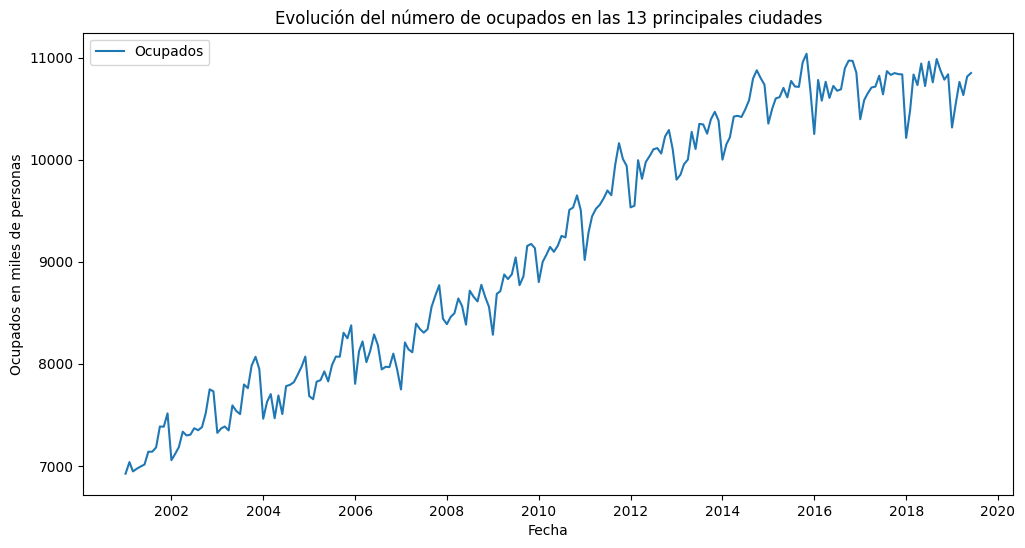

In [ ]:
# ============================================================
# 2.6 Gráfico inicial de la serie Ocupados
# ============================================================

# Se grafica la evolución histórica del número de ocupados.
fig = plt.figure(figsize=(12, 6))

plt.plot(y, label="Ocupados")
plt.title("Evolución del número de ocupados en las 13 principales ciudades")
plt.xlabel("Fecha")
plt.ylabel("Ocupados en miles de personas")
plt.legend()
plt.grid()

plt.show()

**Visualización inicial de la serie**

La gráfica muestra que la serie **Ocupados** presenta una tendencia creciente durante la mayor parte del periodo analizado, pasando de niveles cercanos a **7.000 miles de personas** al inicio de la muestra a valores superiores a **10.000 miles de personas** en los años más recientes. También se observan fluctuaciones recurrentes alrededor de la tendencia, lo que sugiere la posible presencia de componentes estacionales o variaciones propias del mercado laboral. Hacia los últimos años, la serie parece estabilizarse en niveles altos, aunque con algunas caídas puntuales. Esta revisión visual indica que los modelos de pronóstico deben considerar, como mínimo, componentes de **tendencia** y posiblemente de **estacionalidad**, razón por la cual se continuará con la división entre entrenamiento y prueba para evaluar formalmente el desempeño predictivo de los modelos vistos en clase.

# **3. División de la serie en entrenamiento y prueba**

Antes de ajustar los modelos de pronóstico, la serie **Ocupados** se divide en un conjunto de entrenamiento y un conjunto de prueba. Esta división permite evaluar la capacidad predictiva de los modelos sobre datos no utilizados durante la estimación. Dado que el objetivo del ejercicio es pronosticar los próximos seis meses, se reservan las últimas seis observaciones disponibles como conjunto de prueba, manteniendo el orden temporal de la serie.

In [ ]:
# Se define el horizonte de evaluación.
# Dado que el ejercicio solicita pronosticar seis meses, se reservan
# las últimas seis observaciones como conjunto de prueba.
h = 6

# Se construyen los conjuntos de entrenamiento y prueba respetando el orden temporal.
train = y.iloc[:-h]
test = y.iloc[-h:]

# Se imprimen los tamaños de cada conjunto.
print("Número de observaciones en entrenamiento:", train.shape[0])
print("Número de observaciones en prueba:", test.shape[0])

# Se imprime el rango temporal de cada conjunto.
print("\nRango temporal del conjunto de entrenamiento:")
print("Fecha inicial:", train.index.min())
print("Fecha final:", train.index.max())

print("\nRango temporal del conjunto de prueba:")
print("Fecha inicial:", test.index.min())
print("Fecha final:", test.index.max())

Número de observaciones en entrenamiento: 216
Número de observaciones en prueba: 6

Rango temporal del conjunto de entrenamiento:
Fecha inicial: 2001-01-01 00:00:00
Fecha final: 2018-12-01 00:00:00

Rango temporal del conjunto de prueba:
Fecha inicial: 2019-01-01 00:00:00
Fecha final: 2019-06-01 00:00:00


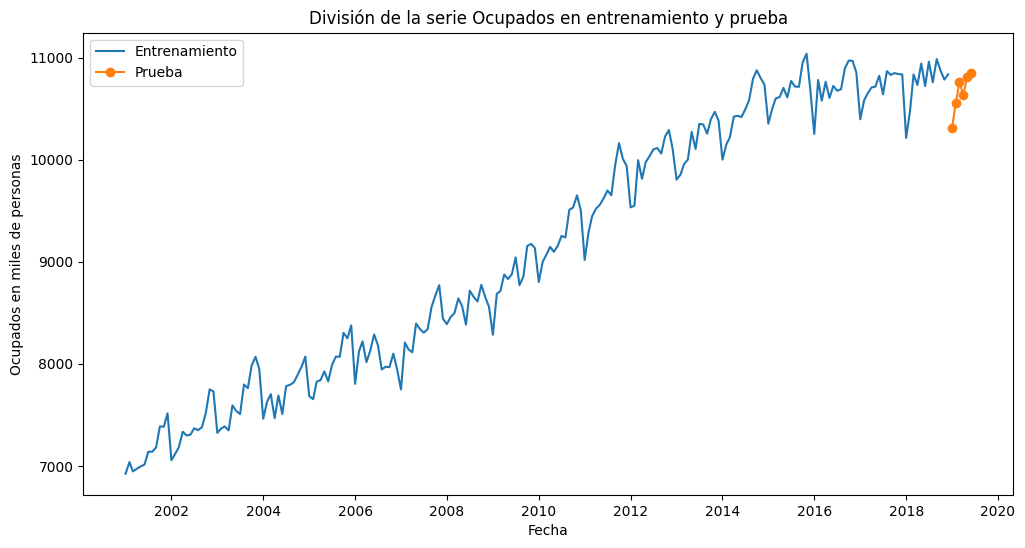

In [ ]:
# Se grafica la serie separando el conjunto de entrenamiento y el conjunto de prueba.
fig = plt.figure(figsize=(12, 6))

plt.plot(train, label="Entrenamiento")
plt.plot(test, label="Prueba", marker="o")

plt.title("División de la serie Ocupados en entrenamiento y prueba")
plt.xlabel("Fecha")
plt.ylabel("Ocupados en miles de personas")
plt.legend()
plt.grid()

plt.show()

**División entrenamiento-prueba**

La serie **Ocupados** se dividió manteniendo su orden temporal. El conjunto de entrenamiento contiene la mayor parte de la información histórica y será utilizado para estimar los modelos. El conjunto de prueba corresponde a las últimas seis observaciones disponibles y permitirá evaluar el desempeño predictivo de cada modelo mediante una métrica de error. Esta estrategia evita evaluar los modelos únicamente sobre los datos usados en su estimación y permite una comparación más objetiva.

# **4. Modelo de tendencia lineal**

En esta sección se estima un modelo de tendencia lineal para la serie **Ocupados**. Este modelo busca representar la evolución de la serie mediante una relación lineal entre el número de ocupados y el tiempo. El ajuste se realiza únicamente con el conjunto de entrenamiento, mientras que el conjunto de prueba se utiliza para evaluar la capacidad predictiva del modelo.

In [ ]:
# Se construye una variable de tiempo para el conjunto de entrenamiento.
# Esta variable representa la posición temporal de cada observación.
x_train = np.arange(1, len(train) + 1)

# Se agrega una constante para estimar el intercepto del modelo.
X_train_lineal = sm.add_constant(x_train)

# Se visualizan las primeras filas de la matriz de variables explicativas.
X_train_lineal[:5]

array([[1., 1.],
       [1., 2.],
       [1., 3.],
       [1., 4.],
       [1., 5.]])

In [ ]:
# Se estima el modelo de regresión lineal usando el conjunto de entrenamiento.
modelo_lineal = sm.OLS(train, X_train_lineal).fit()

# Se presenta el resumen estadístico del modelo.
print(modelo_lineal.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.962
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     5386.
Date:                Thu, 28 May 2026   Prob (F-statistic):          1.10e-153
Time:                        19:43:09   Log-Likelihood:                -1500.2
No. Observations:                 216   AIC:                             3004.
Df Residuals:                     214   BIC:                             3011.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6925.6150     34.477    200.879      0.0

**Estimación del modelo de tendencia lineal**

El modelo de tendencia lineal fue estimado con **216 observaciones** del conjunto de entrenamiento. Los resultados muestran un **R² de 0,962**, lo que indica que el tiempo explica una proporción alta de la variación observada en la serie **Ocupados** dentro del periodo de entrenamiento. El coeficiente asociado a la variable de tiempo es positivo, con un valor aproximado de **20,22**, y resulta estadísticamente significativo, dado que su p-valor es menor a **0,05**. Esto sugiere que, durante el periodo analizado, la serie presenta una tendencia creciente promedio cercana a **20,22 miles de personas por mes**. No obstante, el estadístico **Durbin-Watson de 0,555** anticipa una posible autocorrelación positiva en los residuos, por lo que este modelo deberá evaluarse posteriormente mediante pruebas formales de autocorrelación y compararse con modelos más completos.

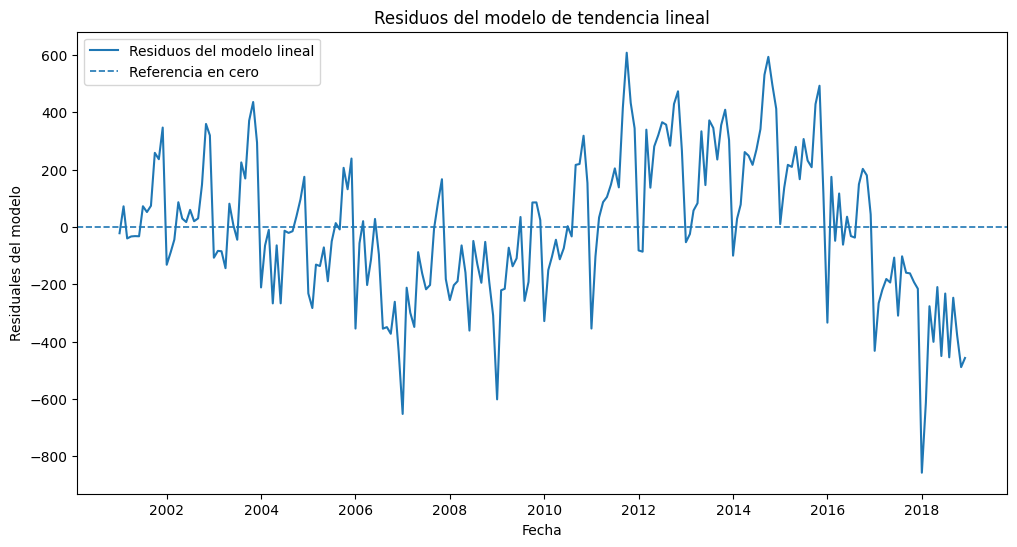

In [ ]:
# Se extraen los residuos del modelo de tendencia lineal.
lineal_resid = modelo_lineal.resid

# Se organizan los residuos como una serie temporal.
lineal_resid = pd.Series(lineal_resid, index=train.index)

# Se grafica la evolución de los residuos del modelo.
plt.figure(figsize=(12, 6))

plt.plot(lineal_resid, label="Residuos del modelo lineal", linewidth=1.5)
plt.axhline(y=0, linestyle="--", linewidth=1.2, label="Referencia en cero")

plt.title("Residuos del modelo de tendencia lineal")
plt.xlabel("Fecha")
plt.ylabel("Residuales del modelo")
plt.legend()
plt.grid()

plt.show()

**Revisión gráfica de los residuos del modelo lineal**

La gráfica de residuos del modelo de tendencia lineal muestra que los errores no se distribuyen de forma completamente aleatoria alrededor de la línea de referencia en cero. Se observan periodos con residuos predominantemente negativos, especialmente entre 2006 y 2009, así como periodos con residuos positivos relevantes entre 2011 y 2015. Hacia el final de la serie aparecen nuevamente residuos negativos de magnitud importante, incluyendo una caída pronunciada alrededor de 2018. Este comportamiento evidencia que el modelo lineal, aunque captura la tendencia general creciente de **Ocupados**, deja patrones sistemáticos sin explicar. Por tanto, el modelo debe considerarse una primera aproximación y será necesario compararlo con alternativas más flexibles, como la tendencia cuadrática y los modelos con estacionalidad.

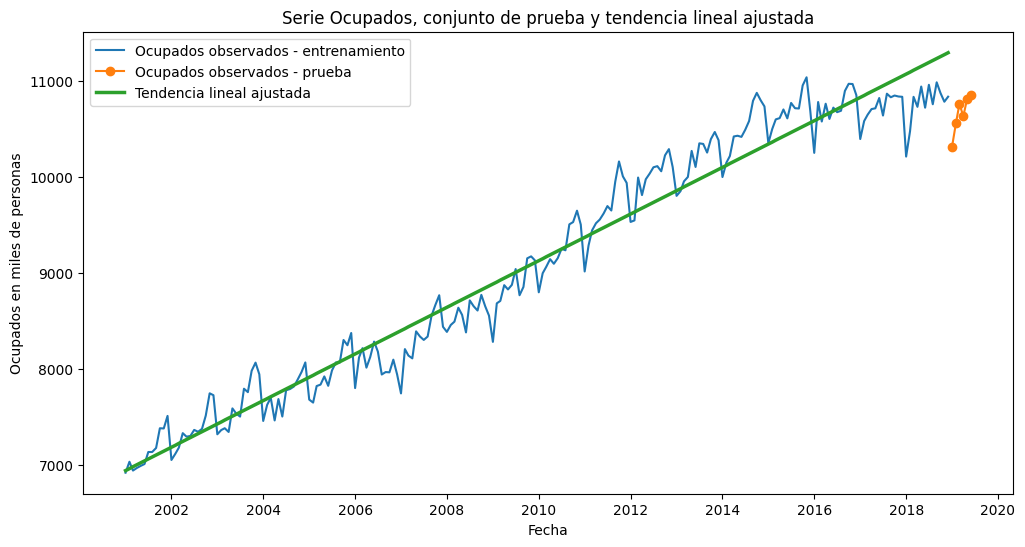

In [ ]:
# Se organizan los valores ajustados del modelo lineal como serie temporal.
ajuste_lineal_train = pd.Series(modelo_lineal.fittedvalues, index=train.index)

# Se grafica la serie observada de entrenamiento, prueba y la tendencia lineal ajustada.
plt.figure(figsize=(12, 6))

plt.plot(train, label="Ocupados observados - entrenamiento", linewidth=1.5)
plt.plot(test, label="Ocupados observados - prueba", marker="o", linewidth=1.5)
plt.plot(ajuste_lineal_train, label="Tendencia lineal ajustada", linewidth=2.5)

plt.title("Serie Ocupados, conjunto de prueba y tendencia lineal ajustada")
plt.xlabel("Fecha")
plt.ylabel("Ocupados en miles de personas")
plt.legend()
plt.grid()

plt.show()

**Ajuste gráfico del modelo de tendencia lineal**

La gráfica compara la serie **Ocupados** del conjunto de entrenamiento, las observaciones reservadas para prueba y la tendencia lineal ajustada. Se observa que el modelo representa adecuadamente la dirección general creciente de la serie durante el periodo de entrenamiento. Sin embargo, la línea recta no captura por completo las fluctuaciones observadas alrededor de la tendencia ni la aparente estabilización de la serie en los años más recientes. Además, frente al conjunto de prueba, la tendencia lineal parece ubicarse por encima de varios valores reales, lo que sugiere una posible sobreestimación del comportamiento reciente de **Ocupados**. Por tanto, este modelo constituye una primera aproximación útil, pero debe compararse con modelos que incorporen curvatura y estacionalidad antes de seleccionarlo como alternativa final de pronóstico.

In [ ]:
# Se define el horizonte de evaluación.
# En este caso corresponde a las seis observaciones reservadas como prueba.
h = len(test)

# Se construye la variable de tiempo para el conjunto de prueba.
# La secuencia continúa después del último periodo utilizado en entrenamiento.
x_test = np.arange(len(train) + 1, len(train) + h + 1)

# Se agrega la constante requerida por el modelo de regresión.
X_test_lineal = sm.add_constant(x_test)

# Se obtiene el pronóstico del modelo lineal sobre el conjunto de prueba.
prediccion_lineal = modelo_lineal.get_prediction(X_test_lineal).summary_frame(alpha=0.05)

# Se construye la tabla de pronóstico con índice temporal del conjunto de prueba.
preds_lineal_test = pd.DataFrame({
    "Point_forecast": prediccion_lineal["mean"].values,
    "lower_95": prediccion_lineal["obs_ci_lower"].values,
    "upper_95": prediccion_lineal["obs_ci_upper"].values
}, index=test.index)

# Se visualiza la tabla de pronósticos.
preds_lineal_test

,Point_forecast,lower_95,upper_95
mes,,,
2019-01-01,"11,313.1163","10,810.8491","11,815.3836"
2019-02-01,"11,333.3352","10,831.0040","11,835.6665"
2019-03-01,"11,353.5541","10,851.1583","11,855.9500"
2019-04-01,"11,373.7730","10,871.3121","11,876.2340"
2019-05-01,"11,393.9919","10,891.4652","11,896.5187"
2019-06-01,"11,414.2108","10,911.6178","11,916.8039"


**Pronóstico del modelo de tendencia lineal sobre el conjunto de prueba**

Con el modelo de tendencia lineal estimado a partir del conjunto de entrenamiento, se generaron pronósticos para las seis observaciones reservadas como conjunto de prueba, correspondientes al periodo comprendido entre **enero de 2019 y junio de 2019**. Los pronósticos puntuales muestran una trayectoria creciente, pasando de aproximadamente **11.313,12** a **11.414,21 miles de personas**. Además, para cada mes se calculó un intervalo de predicción al **95%**, cuyos límites inferiores se ubican alrededor de **10.810,85** a **10.911,62**, y cuyos límites superiores van aproximadamente de **11.815,38** a **11.916,80**. Esta tabla permite contrastar posteriormente los valores pronosticados con los valores reales del conjunto de prueba y calcular una métrica de error, como el **RMSE**, para evaluar el desempeño predictivo del modelo lineal frente a las demás alternativas.

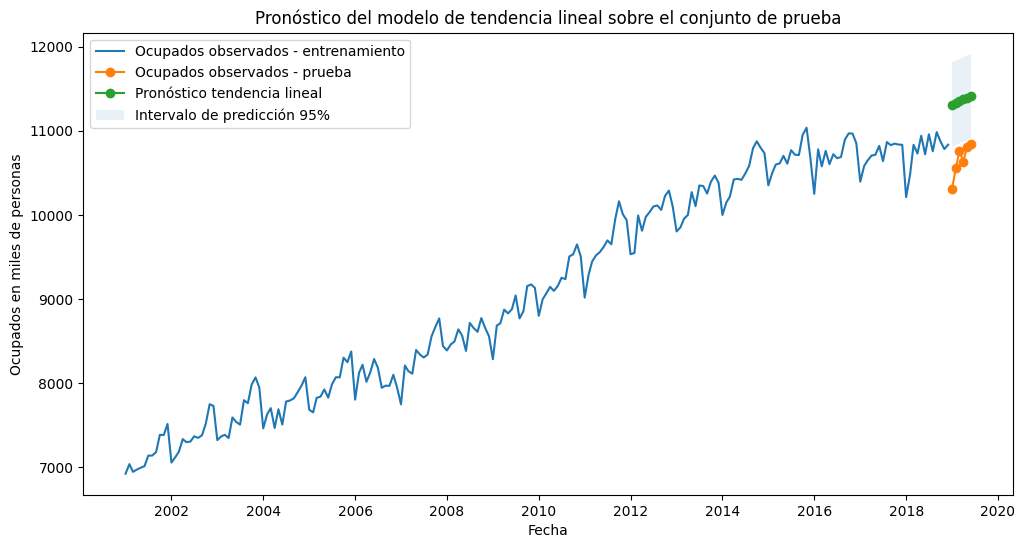

In [ ]:
# Se grafica la serie de entrenamiento, la serie de prueba y el pronóstico lineal.
plt.figure(figsize=(12, 6))

plt.plot(train, label="Ocupados observados - entrenamiento")
plt.plot(test, label="Ocupados observados - prueba", marker="o")
plt.plot(preds_lineal_test["Point_forecast"], label="Pronóstico tendencia lineal", marker="o")

# Se agrega el intervalo de predicción al 95%.
plt.fill_between(
    preds_lineal_test.index,
    preds_lineal_test["lower_95"],
    preds_lineal_test["upper_95"],
    alpha=0.1,
    label="Intervalo de predicción 95%"
)

plt.title("Pronóstico del modelo de tendencia lineal sobre el conjunto de prueba")
plt.xlabel("Fecha")
plt.ylabel("Ocupados en miles de personas")
plt.legend()
plt.grid()

plt.show()

**Pronóstico del modelo de tendencia lineal sobre el conjunto de prueba**

La gráfica muestra el pronóstico generado por el modelo de tendencia lineal para el conjunto de prueba, correspondiente a los seis primeros meses de 2019. Se observa que los pronósticos mantienen una trayectoria creciente y se ubican por encima de los valores reales observados en la mayoría de los meses de prueba. Aunque los valores reales se encuentran dentro del intervalo de predicción al **95%**, la distancia entre la línea pronosticada y la serie observada sugiere que el modelo lineal tiende a **sobrestimar** el número de ocupados en el periodo evaluado. Este resultado confirma que, aunque la tendencia lineal captura la dirección general de largo plazo, puede no representar adecuadamente la estabilización reciente de la serie, por lo que deberá compararse con modelos alternativos antes de definir el mejor pronóstico.

In [ ]:
# Se calcula el RMSE comparando los valores reales de prueba
# contra los pronósticos puntuales del modelo lineal.
rmse_lineal = np.sqrt(mean_squared_error(test, preds_lineal_test["Point_forecast"]))

print("RMSE del modelo de tendencia lineal:", round(rmse_lineal, 4))

RMSE del modelo de tendencia lineal: 725.5285


**Evaluación del error del modelo de tendencia lineal**

El desempeño predictivo del modelo de tendencia lineal se evaluó comparando los valores reales del conjunto de prueba con los pronósticos puntuales generados para los seis primeros meses de 2019. El **RMSE obtenido fue de 725,5285**, lo que significa que, en promedio, el error de pronóstico del modelo se encuentra alrededor de **725,53 miles de personas**. Este valor confirma que, aunque la tendencia lineal captura la dirección general creciente de la serie **Ocupados**, su capacidad predictiva en el periodo de prueba es limitada, especialmente porque tiende a sobrestimar los valores recientes. Por tanto, este resultado servirá como punto de comparación frente a modelos más flexibles, como la tendencia cuadrática y los modelos con estacionalidad.

# **5. Modelo de tendencia cuadrática**

En esta sección se estima un modelo de tendencia cuadrática para la serie **Ocupados**. A diferencia del modelo lineal, este enfoque incorpora tanto el tiempo como el tiempo elevado al cuadrado, permitiendo representar posibles curvaturas en la evolución de la serie. El modelo se estima con el conjunto de entrenamiento y luego se evalúa su capacidad predictiva sobre el conjunto de prueba.

In [ ]:
# Se construye una copia del conjunto de entrenamiento para incluir las variables de tiempo.
train_cuadratico = pd.DataFrame({
    "Ocupados": train
})

# Se crea la variable de tiempo.
train_cuadratico["x"] = np.linspace(1, train_cuadratico.shape[0], train_cuadratico.shape[0])

# Se crea la variable cuadrática.
train_cuadratico["x2"] = train_cuadratico["x"] ** 2

# Se define la variable dependiente.
y_train_cuadratico = train_cuadratico["Ocupados"]

# Se define la matriz de variables explicativas con constante.
X_train_cuadratico = sm.add_constant(train_cuadratico[["x", "x2"]])

# Se visualiza la estructura inicial de la matriz de modelación.
train_cuadratico.head()

,Ocupados,x,x2
mes,,,
2001-01-01,"6,923.6040",1.0000,1.0000
2001-02-01,"7,037.7460",2.0000,4.0000
2001-03-01,"6,945.9730",3.0000,9.0000
2001-04-01,"6,973.0790",4.0000,16.0000
2001-05-01,"6,994.4620",5.0000,25.0000


**Construcción de variables para el modelo de tendencia cuadrática**

La salida confirma que el conjunto de entrenamiento fue organizado correctamente para estimar el modelo cuadrático. Para enero de 2001, la variable de tiempo **x** toma el valor 1 y su cuadrado **x2** también toma el valor 1; para febrero de 2001, **x** toma el valor 2 y **x2** toma el valor 4; y así sucesivamente. De esta manera, el modelo podrá estimar no solo una tendencia lineal asociada al paso del tiempo, sino también una tendencia curva mediante el término **x²**. Esta estructura permitirá evaluar si una trayectoria cuadrática representa mejor la evolución de **Ocupados** que la tendencia lineal simple.

In [ ]:
# Se estima el modelo de tendencia cuadrática usando el conjunto de entrenamiento.
modelo_cuadratico = sm.OLS(y_train_cuadratico, X_train_cuadratico).fit()

# Se presenta el resumen estadístico del modelo.
print(modelo_cuadratico.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     2752.
Date:                Thu, 28 May 2026   Prob (F-statistic):          6.85e-153
Time:                        19:43:12   Log-Likelihood:                -1497.5
No. Observations:                 216   AIC:                             3001.
Df Residuals:                     213   BIC:                             3011.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6835.5053     51.482    132.774      0.0

**Estimación del modelo de tendencia cuadrática**

El modelo de tendencia cuadrática fue estimado con **216 observaciones** del conjunto de entrenamiento, incorporando una variable de tiempo **x** y su término cuadrático **x²**. Los resultados muestran un **R² de 0,963**, muy similar al obtenido con la tendencia lineal, lo que indica que el modelo explica una proporción alta de la variabilidad histórica de **Ocupados**. El coeficiente de **x** es positivo y estadísticamente significativo, con un valor aproximado de **22,699**, mientras que el coeficiente de **x²** es negativo y también significativo, con un p-valor de **0,020**. Esta combinación sugiere que la serie presenta una tendencia creciente, pero con una ligera desaceleración en el tiempo, lo cual es coherente con la estabilización observada en los años más recientes. Sin embargo, el estadístico **Durbin-Watson de 0,569** sigue siendo bajo, lo que anticipa posible autocorrelación positiva en los residuos. Por tanto, aunque el modelo cuadrático mejora la representación conceptual de la serie frente a una recta simple, será necesario evaluar sus residuos y comparar su **RMSE** en el conjunto de prueba antes de considerarlo como modelo candidato final.

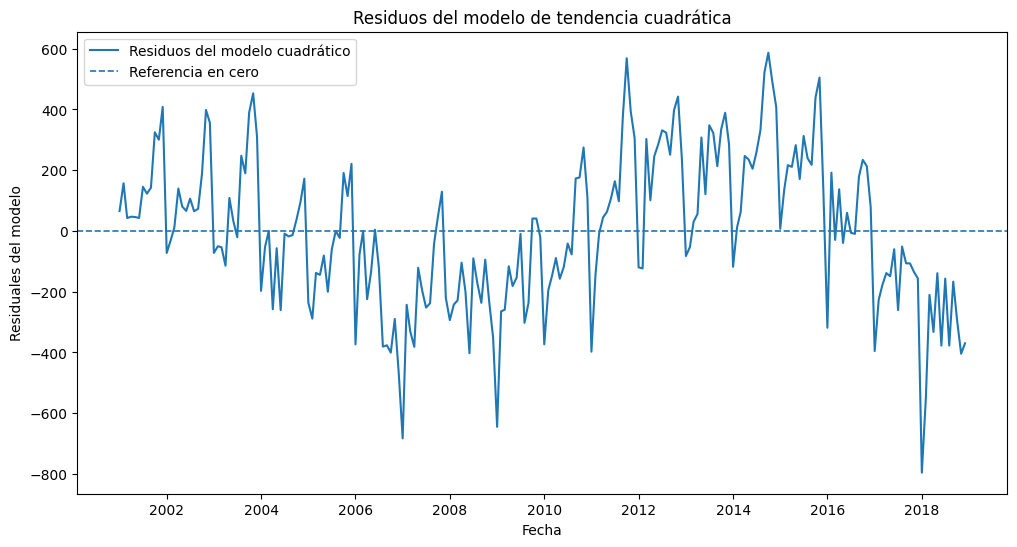

In [ ]:
# Se extraen los residuos del modelo de tendencia cuadrática.
cuadratico_resid = modelo_cuadratico.resid

# Se organizan los residuos como una serie temporal.
cuadratico_resid = pd.Series(cuadratico_resid, index=train.index)

# Se grafican los residuos para revisar visualmente si presentan patrones.
plt.figure(figsize=(12, 6))

plt.plot(cuadratico_resid, label="Residuos del modelo cuadrático", linewidth=1.5)
plt.axhline(y=0, linestyle="--", linewidth=1.2, label="Referencia en cero")

plt.title("Residuos del modelo de tendencia cuadrática")
plt.xlabel("Fecha")
plt.ylabel("Residuales del modelo")
plt.legend()
plt.grid()

plt.show()

**Revisión gráfica de los residuos del modelo cuadrático**

La gráfica de residuos del modelo de tendencia cuadrática muestra que los errores continúan presentando patrones sistemáticos alrededor de la línea de referencia en cero. Se observan tramos con residuos predominantemente negativos, especialmente entre 2006 y 2009, así como periodos con residuos positivos relevantes entre 2011 y 2015. Hacia el final de la serie aparecen nuevamente residuos negativos de magnitud importante, con una caída pronunciada alrededor de 2018. Aunque el modelo cuadrático incorpora una curvatura en la tendencia, estos resultados sugieren que aún no captura completamente la dinámica de la serie **Ocupados**. En particular, podrían permanecer componentes de estacionalidad, cambios de nivel o autocorrelación que deberán evaluarse con pruebas formales y con la comparación del error de pronóstico en el conjunto de prueba.

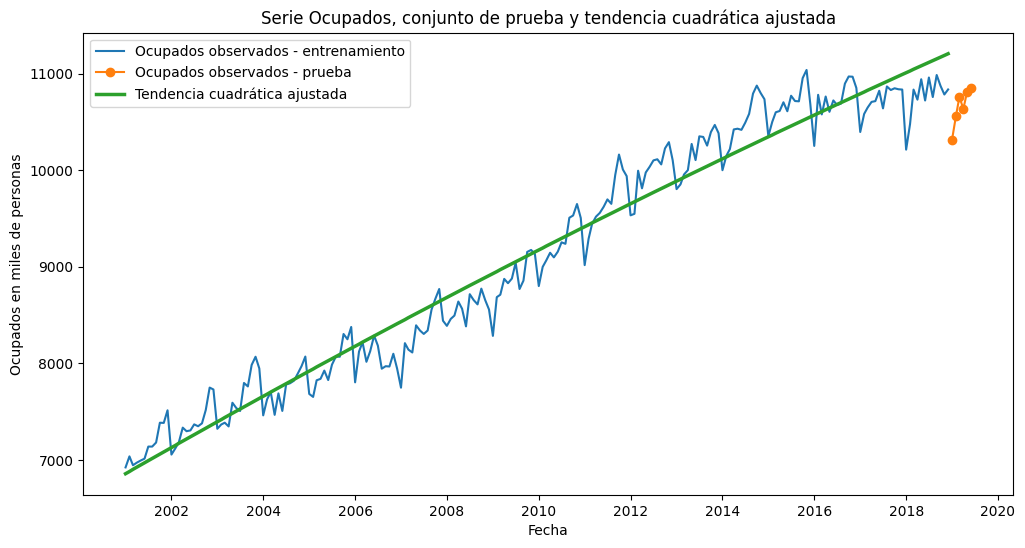

In [ ]:
# Se organizan los valores ajustados del modelo cuadrático como serie temporal.
ajuste_cuadratico_train = pd.Series(modelo_cuadratico.fittedvalues, index=train.index)

# Se grafica la serie observada de entrenamiento, la prueba y la tendencia cuadrática ajustada.
plt.figure(figsize=(12, 6))

plt.plot(train, label="Ocupados observados - entrenamiento", linewidth=1.5)
plt.plot(test, label="Ocupados observados - prueba", marker="o", linewidth=1.5)
plt.plot(ajuste_cuadratico_train, label="Tendencia cuadrática ajustada", linewidth=2.5)

plt.title("Serie Ocupados, conjunto de prueba y tendencia cuadrática ajustada")
plt.xlabel("Fecha")
plt.ylabel("Ocupados en miles de personas")
plt.legend()
plt.grid()

plt.show()

**Ajuste gráfico del modelo de tendencia cuadrática**

La gráfica compara la serie **Ocupados** del conjunto de entrenamiento, las observaciones reservadas para prueba y la tendencia cuadrática ajustada. El modelo conserva la dirección general creciente de la serie y permite una ligera curvatura en la trayectoria, aunque visualmente su comportamiento sigue siendo muy parecido al de la tendencia lineal. En los años más recientes, la curva continúa aumentando, mientras que la serie observada muestra señales de estabilización y algunas caídas puntuales. Frente al conjunto de prueba, la tendencia cuadrática también parece ubicarse por encima de los valores reales, lo que sugiere una posible sobreestimación del nivel reciente de ocupación. Por tanto, aunque este modelo incorpora mayor flexibilidad que la tendencia lineal, todavía debe evaluarse mediante el RMSE y la revisión de residuos antes de considerarlo como alternativa final.

In [ ]:
# Se define el horizonte de evaluación.
# En este caso corresponde a las seis observaciones reservadas como prueba.
h = len(test)

# Se construye la variable de tiempo para el conjunto de prueba.
# La secuencia continúa después del último periodo utilizado en entrenamiento.
x_test = np.arange(len(train) + 1, len(train) + h + 1)

# Se construye la variable cuadrática para el conjunto de prueba.
x2_test = x_test ** 2

# Se construye la matriz de variables explicativas para el conjunto de prueba.
X_test_cuadratico = pd.DataFrame({
    "x": x_test,
    "x2": x2_test
}, index=test.index)

# Se agrega la constante requerida por el modelo de regresión.
X_test_cuadratico = sm.add_constant(X_test_cuadratico)

# Se obtiene el pronóstico del modelo cuadrático sobre el conjunto de prueba.
prediccion_cuadratica = modelo_cuadratico.get_prediction(X_test_cuadratico).summary_frame(alpha=0.05)

# Se construye la tabla de pronóstico con índice temporal del conjunto de prueba.
preds_cuadratico_test = pd.DataFrame({
    "Point_forecast": prediccion_cuadratica["mean"].values,
    "lower_95": prediccion_cuadratica["obs_ci_lower"].values,
    "upper_95": prediccion_cuadratica["obs_ci_upper"].values
}, index=test.index)

# Se visualiza la tabla de pronósticos.
preds_cuadratico_test

,Point_forecast,lower_95,upper_95
mes,,,
2019-01-01,"11,223.0066","10,720.1100","11,725.9031"
2019-02-01,"11,240.7340","10,737.4531","11,744.0148"
2019-03-01,"11,258.4385","10,754.7612","11,762.1158"
2019-04-01,"11,276.1202","10,772.0341","11,780.2062"
2019-05-01,"11,293.7790","10,789.2716","11,798.2863"
2019-06-01,"11,311.4149","10,806.4735","11,816.3564"


**Pronóstico del modelo de tendencia cuadrática sobre el conjunto de prueba**

Con el modelo de tendencia cuadrática estimado a partir del conjunto de entrenamiento, se generaron pronósticos para las seis observaciones reservadas como conjunto de prueba, correspondientes al periodo entre **enero de 2019 y junio de 2019**. Los pronósticos puntuales presentan una trayectoria creciente, pasando de aproximadamente **11.223,01** a **11.311,41 miles de personas**. Para cada mes se calculó además un intervalo de predicción al **95%**, cuyos límites inferiores se ubican entre **10.720,11** y **10.806,47**, mientras que los límites superiores van de **11.725,90** a **11.816,36**. Esta tabla permitirá comparar los valores pronosticados con los valores reales del conjunto de prueba y calcular el **RMSE**, con el fin de evaluar si la tendencia cuadrática mejora el desempeño predictivo frente al modelo de tendencia lineal.

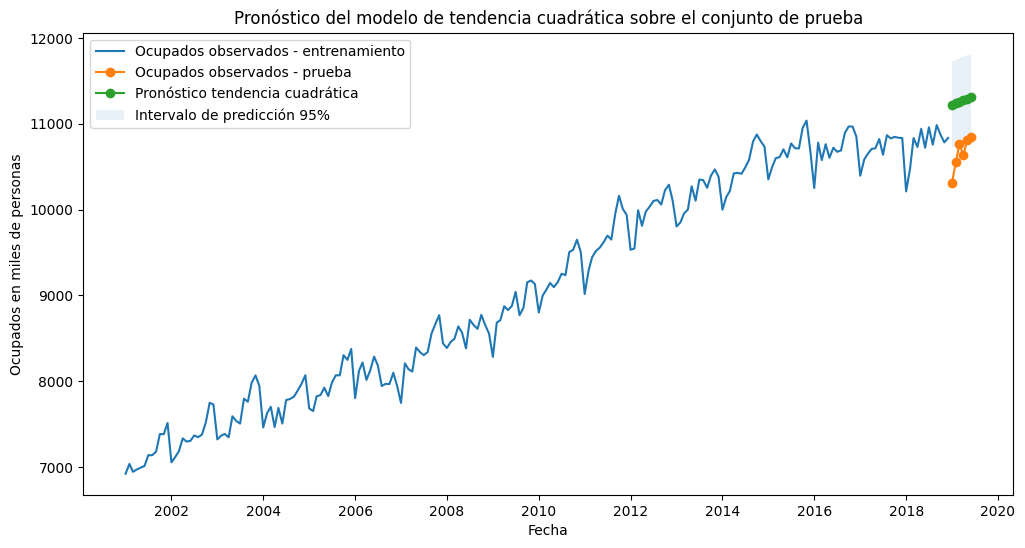

In [ ]:
# Se grafica la serie de entrenamiento, la serie de prueba y el pronóstico cuadrático.
plt.figure(figsize=(12, 6))

plt.plot(train, label="Ocupados observados - entrenamiento")
plt.plot(test, label="Ocupados observados - prueba", marker="o")
plt.plot(preds_cuadratico_test["Point_forecast"], label="Pronóstico tendencia cuadrática", marker="o")

# Se agrega el intervalo de predicción al 95%.
plt.fill_between(
    preds_cuadratico_test.index,
    preds_cuadratico_test["lower_95"],
    preds_cuadratico_test["upper_95"],
    alpha=0.1,
    label="Intervalo de predicción 95%"
)

plt.title("Pronóstico del modelo de tendencia cuadrática sobre el conjunto de prueba")
plt.xlabel("Fecha")
plt.ylabel("Ocupados en miles de personas")
plt.legend()
plt.grid()

plt.show()

**Pronóstico del modelo de tendencia cuadrática sobre el conjunto de prueba**

La gráfica muestra el pronóstico del modelo de tendencia cuadrática para las seis observaciones del conjunto de prueba. Al igual que en el modelo lineal, el pronóstico mantiene una trayectoria creciente y se ubica por encima de los valores reales observados durante el periodo de evaluación. Aunque las observaciones reales se encuentran dentro del intervalo de predicción al **95%**, la distancia entre los valores pronosticados y los datos de prueba sugiere una tendencia a la **sobrestimación**. Esto indica que la incorporación del término cuadrático mejora la flexibilidad del modelo, pero no necesariamente corrige por completo la estabilización reciente de la serie **Ocupados**. Por tanto, su desempeño deberá confirmarse mediante el cálculo del **RMSE** y compararse con los demás modelos candidatos.

In [ ]:
# Se calcula el RMSE comparando los valores reales de prueba
# contra los pronósticos puntuales del modelo cuadrático.
rmse_cuadratico = np.sqrt(mean_squared_error(test, preds_cuadratico_test["Point_forecast"]))

print("RMSE del modelo de tendencia cuadrática:", round(rmse_cuadratico, 4))

RMSE del modelo de tendencia cuadrática: 632.4767


**Evaluación del error del modelo de tendencia cuadrática**

El desempeño predictivo del modelo de tendencia cuadrática se evaluó comparando los valores reales del conjunto de prueba con los pronósticos puntuales generados para los seis primeros meses de 2019. El **RMSE obtenido fue de 632,4767**, lo que indica que el error promedio de pronóstico se ubica alrededor de **632,48 miles de personas**. Este resultado es menor que el RMSE del modelo de tendencia lineal, que fue de **725,5285**, por lo que la incorporación del término cuadrático mejora el desempeño predictivo en el conjunto de prueba. Sin embargo, la gráfica de pronóstico y la revisión de residuos muestran que el modelo aún tiende a sobrestimar los valores recientes y deja patrones sin explicar. Por tanto, aunque el modelo cuadrático representa una mejora frente al lineal, todavía debe compararse con modelos que incorporen estacionalidad.

# **6. Modelo de estacionalidad mensual**

En esta sección se estima un modelo de estacionalidad mensual para la serie **Ocupados**. Este modelo utiliza variables indicadoras para los meses del año, con el propósito de identificar si existen diferencias sistemáticas entre los meses. Enero se toma como mes de referencia, por lo que los coeficientes de los demás meses representan diferencias promedio frente a enero. El modelo se estima con el conjunto de entrenamiento y posteriormente se evaluará sobre el conjunto de prueba.

In [ ]:
# Se crean variables indicadoras mensuales para el conjunto de entrenamiento.
# Enero queda como mes de referencia porque se elimina la primera categoría.
month_dummies_train = pd.get_dummies(
    train.index.month,
    drop_first=True,
    dtype=float
).set_index(train.index)

# Se define la variable dependiente.
y_train_estacional = train

# Se define la matriz de variables explicativas con constante.
X_train_estacional = sm.add_constant(month_dummies_train)

# Se estima el modelo de estacionalidad mensual.
modelo_estacional = sm.OLS(y_train_estacional, X_train_estacional).fit()

# Se presenta el resumen estadístico del modelo.
print(modelo_estacional.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                 -0.032
Method:                 Least Squares   F-statistic:                    0.3897
Date:                Thu, 28 May 2026   Prob (F-statistic):              0.959
Time:                        19:43:14   Log-Likelihood:                -1850.6
No. Observations:                 216   AIC:                             3725.
Df Residuals:                     204   BIC:                             3766.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8724.5387    308.558     28.275      0.0

**Estimación del modelo de estacionalidad mensual**

El modelo de estacionalidad mensual fue estimado con **216 observaciones** del conjunto de entrenamiento, utilizando variables indicadoras para los meses del año y tomando **enero** como mes de referencia. Los resultados muestran un **R² de 0,021**, lo que indica que las variables mensuales explican una proporción muy baja de la variabilidad de la serie **Ocupados**. Además, el p-valor global del modelo es **0,959**, por lo que no hay evidencia estadística suficiente para afirmar que el conjunto de meses explique significativamente el comportamiento de la serie. Aunque los coeficientes mensuales son positivos frente a enero, ninguno resulta estadísticamente significativo al nivel del 5%. Esto sugiere que, por sí sola, la estacionalidad mensual no logra explicar adecuadamente la dinámica de **Ocupados**, especialmente porque la serie presenta una tendencia creciente de largo plazo que este modelo no incorpora. Por tanto, este modelo debe evaluarse principalmente como referencia y compararse con alternativas que combinen tendencia y estacionalidad.

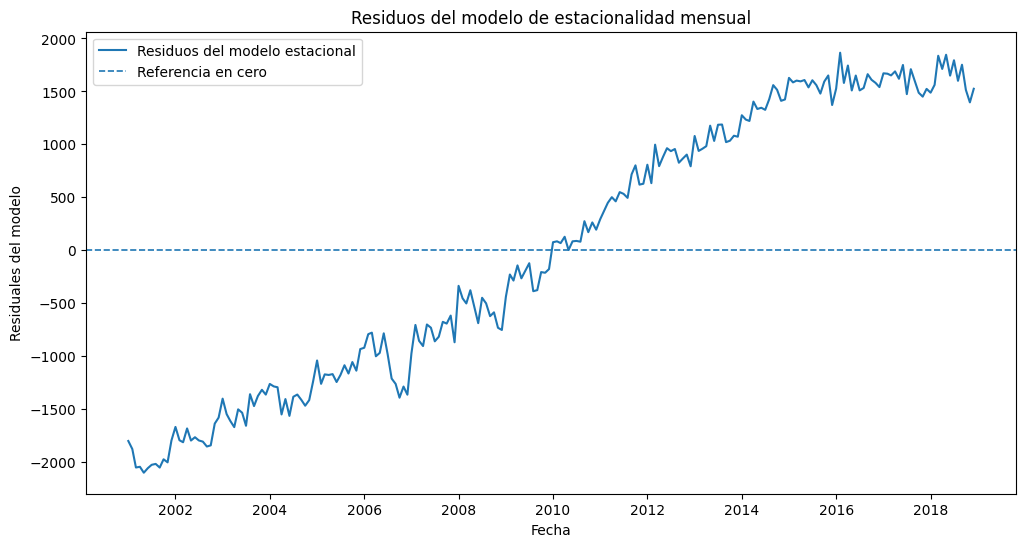

In [ ]:
# Se extraen los residuos del modelo de estacionalidad mensual.
estacional_resid = modelo_estacional.resid

# Se organizan los residuos como una serie temporal.
estacional_resid = pd.Series(estacional_resid, index=train.index)

# Se grafican los residuos para revisar visualmente si presentan patrones.
plt.figure(figsize=(12, 6))

plt.plot(estacional_resid, label="Residuos del modelo estacional", linewidth=1.5)
plt.axhline(y=0, linestyle="--", linewidth=1.2, label="Referencia en cero")

plt.title("Residuos del modelo de estacionalidad mensual")
plt.xlabel("Fecha")
plt.ylabel("Residuales del modelo")
plt.legend()
plt.grid()

plt.show()

**Revisión gráfica de los residuos del modelo estacional**

La gráfica de residuos del modelo de estacionalidad mensual muestra un patrón claramente sistemático y no aleatorio. Al inicio del periodo, los residuos son ampliamente negativos, con valores cercanos a **-2.000**, mientras que a partir de 2010 comienzan a ubicarse por encima de cero y alcanzan niveles positivos superiores a **1.500** en los años posteriores. Este comportamiento confirma que el modelo de estacionalidad mensual, por sí solo, no logra capturar la tendencia creciente de la serie **Ocupados**. En consecuencia, aunque las variables mensuales permiten representar posibles diferencias entre meses, el modelo deja sin explicar una parte importante de la dinámica temporal. Por esta razón, este modelo no parece suficiente como alternativa final y se justifica estimar un modelo combinado que incorpore simultáneamente **tendencia** y **estacionalidad**.

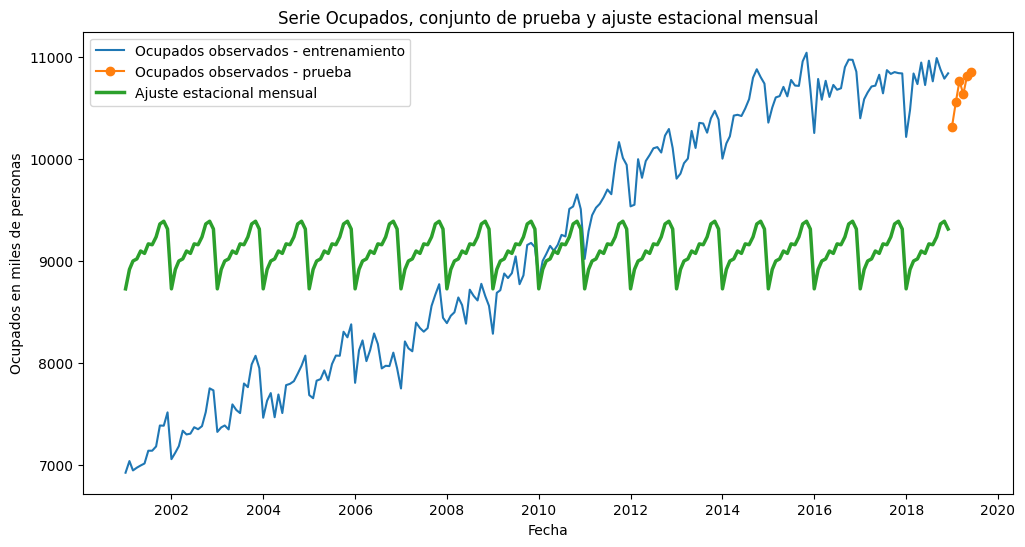

In [ ]:
# Se organizan los valores ajustados del modelo estacional como serie temporal.
ajuste_estacional_train = pd.Series(modelo_estacional.fittedvalues, index=train.index)

# Se grafica la serie observada de entrenamiento, la prueba y el ajuste estacional.
plt.figure(figsize=(12, 6))

plt.plot(train, label="Ocupados observados - entrenamiento", linewidth=1.5)
plt.plot(test, label="Ocupados observados - prueba", marker="o", linewidth=1.5)
plt.plot(ajuste_estacional_train, label="Ajuste estacional mensual", linewidth=2.5)

plt.title("Serie Ocupados, conjunto de prueba y ajuste estacional mensual")
plt.xlabel("Fecha")
plt.ylabel("Ocupados en miles de personas")
plt.legend()
plt.grid()

plt.show()

**Ajuste gráfico del modelo de estacionalidad mensual**

La gráfica compara la serie **Ocupados** del conjunto de entrenamiento, las observaciones reservadas para prueba y el ajuste generado por el modelo de estacionalidad mensual. Se observa que el modelo reproduce un patrón repetitivo anual, reflejado en los ciclos que se repiten de forma similar cada año. Sin embargo, el ajuste se mantiene alrededor de un nivel relativamente estable, cercano a los **9.000 miles de personas**, y no logra seguir la tendencia creciente de la serie observada. En los primeros años, el ajuste estacional se ubica por encima de los datos reales, mientras que en los años más recientes queda muy por debajo de los niveles observados y del conjunto de prueba. Esto confirma que la estacionalidad mensual por sí sola no es suficiente para explicar la evolución de **Ocupados**, por lo que se requiere un modelo que combine la tendencia de largo plazo con los efectos mensuales.

In [ ]:
# Se construyen las variables indicadoras mensuales para el conjunto de prueba.
# Deben tener la misma estructura que las variables usadas en el entrenamiento.
month_dummies_test = pd.get_dummies(
    test.index.month,
    drop_first=True,
    dtype=float
).set_index(test.index)

# Se garantiza que el conjunto de prueba tenga las mismas columnas que el conjunto de entrenamiento.
month_dummies_test = month_dummies_test.reindex(
    columns=month_dummies_train.columns,
    fill_value=0
)

# Se define la matriz de variables explicativas con constante.
X_test_estacional = sm.add_constant(month_dummies_test, has_constant="add")

# Se obtiene el pronóstico del modelo estacional sobre el conjunto de prueba.
prediccion_estacional = modelo_estacional.get_prediction(X_test_estacional).summary_frame(alpha=0.05)

# Se construye la tabla de pronóstico con índice temporal del conjunto de prueba.
preds_estacional_test = pd.DataFrame({
    "Point_forecast": prediccion_estacional["mean"].values,
    "lower_95": prediccion_estacional["obs_ci_lower"].values,
    "upper_95": prediccion_estacional["obs_ci_upper"].values
}, index=test.index)

# Se visualiza la tabla de pronósticos.
preds_estacional_test

,Point_forecast,lower_95,upper_95
mes,,,
2019-01-01,"8,724.5387","6,072.7088","11,376.3687"
2019-02-01,"8,914.5444","6,262.7144","11,566.3743"
2019-03-01,"8,997.2183","6,345.3884","11,649.0483"
2019-04-01,"9,017.6817","6,365.8518","11,669.5117"
2019-05-01,"9,095.0890","6,443.2590","11,746.9190"
2019-06-01,"9,071.7890","6,419.9590","11,723.6190"


**Pronóstico del modelo de estacionalidad mensual sobre el conjunto de prueba**

Con el modelo de estacionalidad mensual estimado a partir del conjunto de entrenamiento, se generaron pronósticos para las seis observaciones reservadas como conjunto de prueba. Para ello, se construyeron las variables indicadoras correspondientes a los meses del periodo de prueba, manteniendo la misma estructura utilizada durante la estimación. Este pronóstico permite evaluar si los efectos mensuales, por sí solos, son suficientes para anticipar el comportamiento reciente de la serie **Ocupados**.

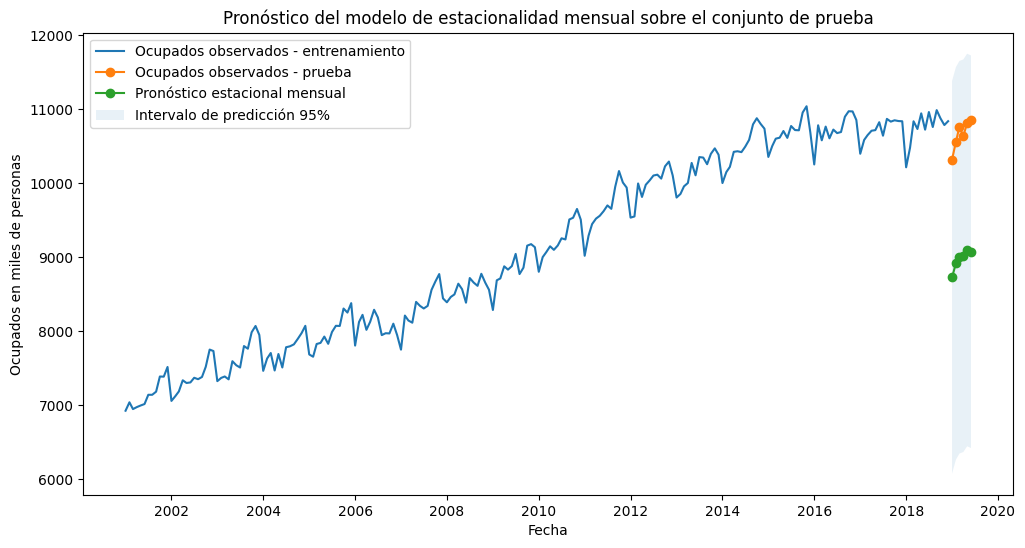

In [ ]:
# Se grafica la serie de entrenamiento, la serie de prueba y el pronóstico estacional.
plt.figure(figsize=(12, 6))

plt.plot(train, label="Ocupados observados - entrenamiento")
plt.plot(test, label="Ocupados observados - prueba", marker="o")
plt.plot(preds_estacional_test["Point_forecast"], label="Pronóstico estacional mensual", marker="o")

# Se agrega el intervalo de predicción al 95%.
plt.fill_between(
    preds_estacional_test.index,
    preds_estacional_test["lower_95"],
    preds_estacional_test["upper_95"],
    alpha=0.1,
    label="Intervalo de predicción 95%"
)

plt.title("Pronóstico del modelo de estacionalidad mensual sobre el conjunto de prueba")
plt.xlabel("Fecha")
plt.ylabel("Ocupados en miles de personas")
plt.legend()
plt.grid()

plt.show()

**Pronóstico del modelo de estacionalidad mensual sobre el conjunto de prueba**

La gráfica muestra que el pronóstico del modelo de estacionalidad mensual se ubica considerablemente por debajo de los valores reales observados en el conjunto de prueba. Mientras los datos reales de **Ocupados** se encuentran alrededor de niveles superiores a **10.000 miles de personas**, el pronóstico estacional se mantiene cerca de **9.000 miles de personas**. Esto confirma que el modelo solo reproduce el patrón mensual promedio, pero no incorpora la tendencia creciente acumulada durante el periodo histórico. Aunque el intervalo de predicción al **95%** es amplio y alcanza a cubrir los valores reales, el pronóstico puntual evidencia una subestimación importante. Por tanto, este modelo no parece adecuado como alternativa final y refuerza la necesidad de estimar un modelo combinado que incluya tanto **tendencia** como **estacionalidad**.

In [ ]:
# Se calcula el RMSE comparando los valores reales de prueba
# contra los pronósticos puntuales del modelo estacional.
rmse_estacional = np.sqrt(mean_squared_error(test, preds_estacional_test["Point_forecast"]))

print("RMSE del modelo de estacionalidad mensual:", round(rmse_estacional, 4))

RMSE del modelo de estacionalidad mensual: 1685.7662


**Evaluación del error del modelo de estacionalidad mensual**

El desempeño predictivo del modelo de estacionalidad mensual se evaluó comparando los valores reales del conjunto de prueba con los pronósticos puntuales generados para los seis primeros meses de 2019. El **RMSE obtenido fue de 1.685,7662**, lo que indica un error promedio aproximado de **1.685,77 miles de personas**. Este resultado es considerablemente superior al obtenido con los modelos de tendencia lineal y tendencia cuadrática, lo que confirma que la estacionalidad mensual por sí sola no explica adecuadamente el comportamiento reciente de la serie **Ocupados**. La principal limitación de este modelo es que reproduce diferencias promedio entre meses, pero no incorpora la tendencia creciente de largo plazo. Por tanto, este modelo no se perfila como candidato final y se justifica avanzar hacia un modelo combinado de **tendencia y estacionalidad**.

# **7. Modelo de tendencia cuadrática más estacionalidad mensual**

En esta sección se estima un modelo combinado que incorpora una tendencia cuadrática y efectos estacionales mensuales. Este modelo busca capturar simultáneamente la evolución de largo plazo de la serie **Ocupados** y las posibles diferencias sistemáticas entre los meses del año. La tendencia se representa mediante las variables **x** y **x²**, mientras que la estacionalidad se incorpora mediante variables indicadoras mensuales. El modelo se estima con el conjunto de entrenamiento y posteriormente se evalúa sobre el conjunto de prueba.

In [ ]:
# Se construye una copia del conjunto de entrenamiento para incluir las variables del modelo.
train_comb = pd.DataFrame({
    "Ocupados": train
})

# Se crea la variable de tiempo.
train_comb["x"] = np.linspace(1, train_comb.shape[0], train_comb.shape[0])

# Se crea la variable cuadrática.
train_comb["x2"] = train_comb["x"] ** 2

# Se crean variables indicadoras mensuales.
# Enero queda como mes de referencia porque se elimina la primera categoría.
month_dummies_train_comb = pd.get_dummies(
    train_comb.index.month,
    drop_first=True,
    dtype=float
).set_index(train_comb.index)

# Se construye la matriz de variables explicativas combinando tendencia y estacionalidad.
X_train_comb = pd.concat(
    [train_comb[["x", "x2"]], month_dummies_train_comb],
    axis=1
)

# Se agrega la constante requerida por el modelo de regresión.
X_train_comb = sm.add_constant(X_train_comb)

# Se define la variable dependiente.
y_train_comb = train_comb["Ocupados"]

# Se visualiza la estructura inicial de la matriz de modelación.
X_train_comb.head()

,const,x,x2,2,3,4,5,6,7,8,9,10,11,12
mes,,,,,,,,,,,,,,
2001-01-01,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2001-02-01,1.0000,2.0000,4.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2001-03-01,1.0000,3.0000,9.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2001-04-01,1.0000,4.0000,16.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2001-05-01,1.0000,5.0000,25.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


**Construcción de variables para el modelo combinado**

La salida muestra la matriz de variables explicativas utilizada para estimar el modelo combinado de **tendencia cuadrática más estacionalidad mensual**. La columna **const** corresponde a la constante del modelo; las variables **x** y **x²** representan la evolución temporal de la serie y permiten capturar tanto la tendencia general como una posible curvatura en el comportamiento de **Ocupados**. Las columnas numeradas del **2** al **12** corresponden a las variables indicadoras de los meses de febrero a diciembre, mientras que enero queda como mes de referencia. Por ejemplo, para febrero de 2001 la columna **2** toma el valor 1, y para marzo de 2001 la columna **3** toma el valor 1. Esta estructura permite que el modelo incorpore simultáneamente el crecimiento de largo plazo y las diferencias promedio entre meses.

In [ ]:
# Se estima el modelo combinado usando el conjunto de entrenamiento.
modelo_comb = sm.OLS(y_train_comb, X_train_comb).fit()

# Se presenta el resumen estadístico del modelo.
print(modelo_comb.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                     528.1
Date:                Thu, 28 May 2026   Prob (F-statistic):          4.37e-148
Time:                        19:43:18   Log-Likelihood:                -1468.9
No. Observations:                 216   AIC:                             2966.
Df Residuals:                     202   BIC:                             3013.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6562.0204     68.138     96.304      0.0

**Estimación del modelo de tendencia cuadrática más estacionalidad mensual**

El modelo combinado fue estimado con **216 observaciones** del conjunto de entrenamiento e incorpora simultáneamente la tendencia temporal, mediante las variables **x** y **x²**, y la estacionalidad mensual, mediante variables indicadoras para los meses de febrero a diciembre, tomando enero como referencia. Los resultados muestran un **R² de 0,971** y un **R² ajustado de 0,970**, superiores a los obtenidos en los modelos anteriores, lo que indica una mejor capacidad explicativa dentro del conjunto de entrenamiento. La variable **x** presenta un coeficiente positivo y significativo, mientras que **x²** tiene un coeficiente negativo y también significativo, lo que sugiere una tendencia creciente con cierta desaceleración en el tiempo. Además, todos los efectos mensuales resultan estadísticamente significativos al 5%, lo cual evidencia que existen diferencias sistemáticas entre los meses del año. Sin embargo, el estadístico **Durbin-Watson de 0,344** sigue siendo bajo, por lo que podrían persistir problemas de autocorrelación en los residuos. En consecuencia, aunque este modelo mejora el ajuste al combinar tendencia y estacionalidad, su selección final dependerá del **RMSE** en el conjunto de prueba y de la evaluación formal de los supuestos de los residuos.

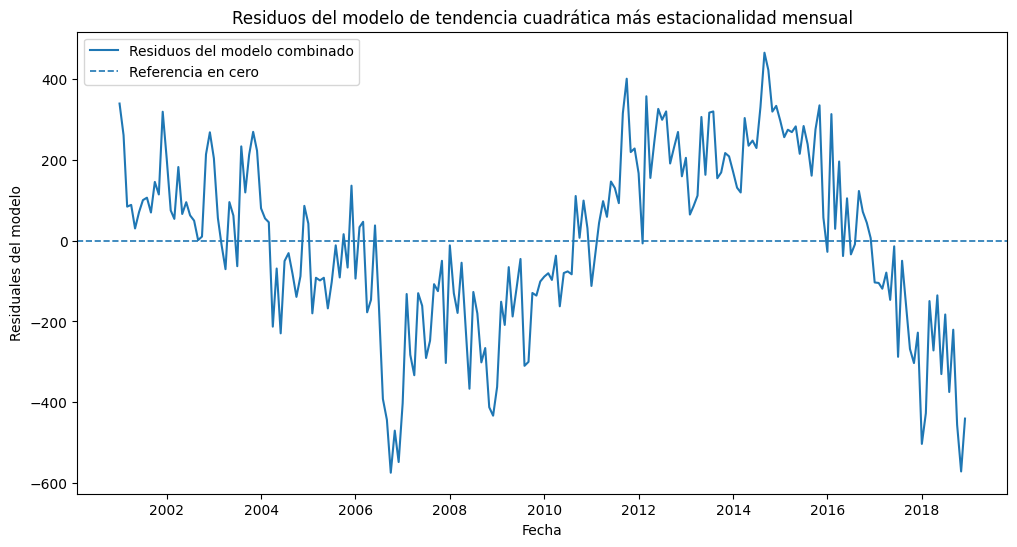

In [ ]:
# Se extraen los residuos del modelo de tendencia cuadrática más estacionalidad mensual.
comb_resid = modelo_comb.resid

# Se organizan los residuos como una serie temporal.
comb_resid = pd.Series(comb_resid, index=train.index)

# Se grafican los residuos para revisar visualmente si presentan patrones.
plt.figure(figsize=(12, 6))

plt.plot(comb_resid, label="Residuos del modelo combinado", linewidth=1.5)
plt.axhline(y=0, linestyle="--", linewidth=1.2, label="Referencia en cero")

plt.title("Residuos del modelo de tendencia cuadrática más estacionalidad mensual")
plt.xlabel("Fecha")
plt.ylabel("Residuales del modelo")
plt.legend()
plt.grid()

plt.show()

**Revisión gráfica de los residuos del modelo combinado**

La gráfica de residuos del modelo de tendencia cuadrática más estacionalidad mensual muestra una mejora frente al modelo puramente estacional, ya que los errores se concentran en un rango más reducido y fluctúan con mayor cercanía alrededor de la línea de referencia en cero. Sin embargo, todavía se observan patrones por periodos: residuos positivos al inicio de la serie, valores negativos importantes entre 2006 y 2009, una fase positiva entre 2011 y 2015, y nuevamente residuos negativos hacia los años más recientes. Esto indica que, aunque el modelo combinado captura mejor la tendencia y los efectos mensuales, aún puede quedar estructura sin explicar en los residuos, posiblemente asociada a autocorrelación, cambios de nivel o choques específicos del mercado laboral. Por tanto, este modelo debe evaluarse adicionalmente mediante pruebas formales de autocorrelación, homoscedasticidad y normalidad antes de tomar una decisión final.

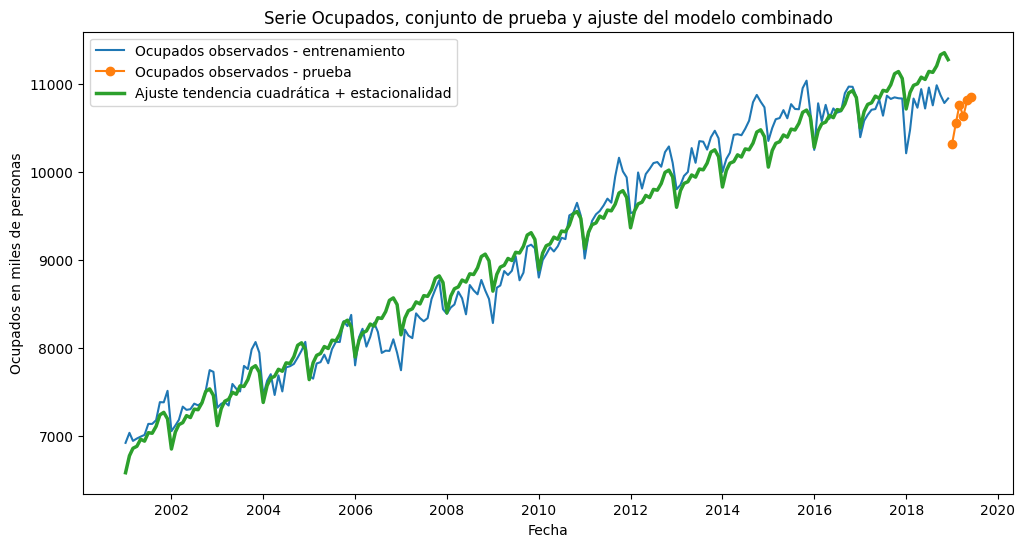

In [ ]:
# Se organizan los valores ajustados del modelo combinado como serie temporal.
ajuste_comb_train = pd.Series(modelo_comb.fittedvalues, index=train.index)

# Se grafica la serie observada de entrenamiento, prueba y el ajuste del modelo combinado.
plt.figure(figsize=(12, 6))

plt.plot(train, label="Ocupados observados - entrenamiento", linewidth=1.5)
plt.plot(test, label="Ocupados observados - prueba", marker="o", linewidth=1.5)
plt.plot(ajuste_comb_train, label="Ajuste tendencia cuadrática + estacionalidad", linewidth=2.5)

plt.title("Serie Ocupados, conjunto de prueba y ajuste del modelo combinado")
plt.xlabel("Fecha")
plt.ylabel("Ocupados en miles de personas")
plt.legend()
plt.grid()

plt.show()

**Ajuste gráfico del modelo combinado**

La gráfica muestra que el modelo de tendencia cuadrática más estacionalidad mensual logra representar mejor la dinámica histórica de la serie **Ocupados** frente a los modelos estimados previamente. A diferencia del modelo puramente estacional, este ajuste sí sigue la trayectoria creciente de largo plazo, y a diferencia de las tendencias lineal y cuadrática simples, incorpora fluctuaciones mensuales que se aproximan mejor al comportamiento observado. Sin embargo, hacia los últimos años el ajuste tiende a ubicarse por encima de varios valores reales, especialmente cerca del conjunto de prueba, lo que sugiere una posible sobreestimación del nivel reciente de ocupación. Por tanto, aunque visualmente el modelo combinado ofrece un ajuste más completo, su selección final debe depender del **RMSE** en prueba y de la evaluación de los supuestos de los residuos.

In [ ]:
# Se define el horizonte de evaluación.
# Corresponde a las seis observaciones reservadas como conjunto de prueba.
h = len(test)

# Se construye la variable de tiempo para el conjunto de prueba.
# La secuencia continúa después del último periodo usado en entrenamiento.
x_test = np.arange(len(train) + 1, len(train) + h + 1)

# Se construye la variable cuadrática para el conjunto de prueba.
x2_test = x_test ** 2

# Se construye la matriz con las variables de tendencia para el conjunto de prueba.
X_test_tendencia = pd.DataFrame({
    "x": x_test,
    "x2": x2_test
}, index=test.index)

# Se construyen las variables indicadoras mensuales para el conjunto de prueba.
month_dummies_test_comb = pd.get_dummies(
    test.index.month,
    drop_first=True,
    dtype=float
).set_index(test.index)

# Se garantiza que las variables mensuales del conjunto de prueba tengan
# las mismas columnas que las utilizadas en el entrenamiento.
month_dummies_test_comb = month_dummies_test_comb.reindex(
    columns=month_dummies_train_comb.columns,
    fill_value=0
)

# Se combinan las variables de tendencia y estacionalidad.
X_test_comb = pd.concat(
    [X_test_tendencia, month_dummies_test_comb],
    axis=1
)

# Se agrega la constante requerida por el modelo.
X_test_comb = sm.add_constant(X_test_comb, has_constant="add")

# Se visualiza la matriz construida para el conjunto de prueba.
X_test_comb

,const,x,x2,2,3,4,5,6,7,8,9,10,11,12
mes,,,,,,,,,,,,,,
2019-01-01,1.0000,217,47089,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0,0,0,0
2019-02-01,1.0000,218,47524,1.0000,0.0000,0.0000,0.0000,0.0000,0,0,0,0,0,0
2019-03-01,1.0000,219,47961,0.0000,1.0000,0.0000,0.0000,0.0000,0,0,0,0,0,0
2019-04-01,1.0000,220,48400,0.0000,0.0000,1.0000,0.0000,0.0000,0,0,0,0,0,0
2019-05-01,1.0000,221,48841,0.0000,0.0000,0.0000,1.0000,0.0000,0,0,0,0,0,0
2019-06-01,1.0000,222,49284,0.0000,0.0000,0.0000,0.0000,1.0000,0,0,0,0,0,0


**Construcción de la matriz de prueba para el modelo combinado**

La salida muestra la matriz de variables explicativas construida para el conjunto de prueba, correspondiente al periodo entre **enero de 2019 y junio de 2019**. La columna **const** representa la constante del modelo, mientras que **x** continúa la secuencia temporal del conjunto de entrenamiento, tomando valores de **217** a **222**. La variable **x²** corresponde al cuadrado de dicha secuencia y permite conservar el componente cuadrático del modelo. Las columnas mensuales identifican el mes de cada observación: enero queda como categoría de referencia, febrero activa la columna **2**, marzo la columna **3**, y así sucesivamente hasta junio. Esta matriz conserva la misma estructura utilizada en la estimación, lo que permite generar pronósticos comparables para las seis observaciones reservadas como prueba.

In [ ]:
# Se obtiene el pronóstico del modelo combinado sobre el conjunto de prueba.
prediccion_comb = modelo_comb.get_prediction(X_test_comb).summary_frame(alpha=0.05)

# Se construye la tabla de pronóstico con índice temporal del conjunto de prueba.
preds_comb_test = pd.DataFrame({
    "Point_forecast": prediccion_comb["mean"].values,
    "lower_95": prediccion_comb["obs_ci_lower"].values,
    "upper_95": prediccion_comb["obs_ci_upper"].values
}, index=test.index)

# Se visualiza la tabla de pronósticos.
preds_comb_test

,Point_forecast,lower_95,upper_95
mes,,,
2019-01-01,"10,928.9846","10,465.3103","11,392.6590"
2019-02-01,"11,116.3897","10,652.4205","11,580.3590"
2019-03-01,"11,196.4631","10,732.1907","11,660.7356"
2019-04-01,"11,214.3259","10,749.7421","11,678.9098"
2019-05-01,"11,289.1326","10,824.2292","11,754.0361"
2019-06-01,"11,263.2321","10,798.0009","11,728.4633"


**Pronóstico del modelo combinado sobre el conjunto de prueba**

Con el modelo de tendencia cuadrática más estacionalidad mensual se generaron pronósticos para las seis observaciones del conjunto de prueba, correspondientes al periodo entre **enero de 2019 y junio de 2019**. Los pronósticos puntuales se ubican entre aproximadamente **10.928,98** y **11.289,13 miles de personas**, con una trayectoria que incorpora tanto el efecto temporal como las diferencias mensuales. Para cada periodo se calculó un intervalo de predicción al **95%**, cuyos límites inferiores se encuentran entre **10.465,31** y **10.824,23**, mientras que los límites superiores oscilan entre **11.392,66** y **11.754,04**. Esta tabla permite comparar el desempeño del modelo combinado frente a los valores reales de prueba y evaluar si la incorporación simultánea de tendencia y estacionalidad mejora el error de pronóstico respecto a los modelos anteriores.

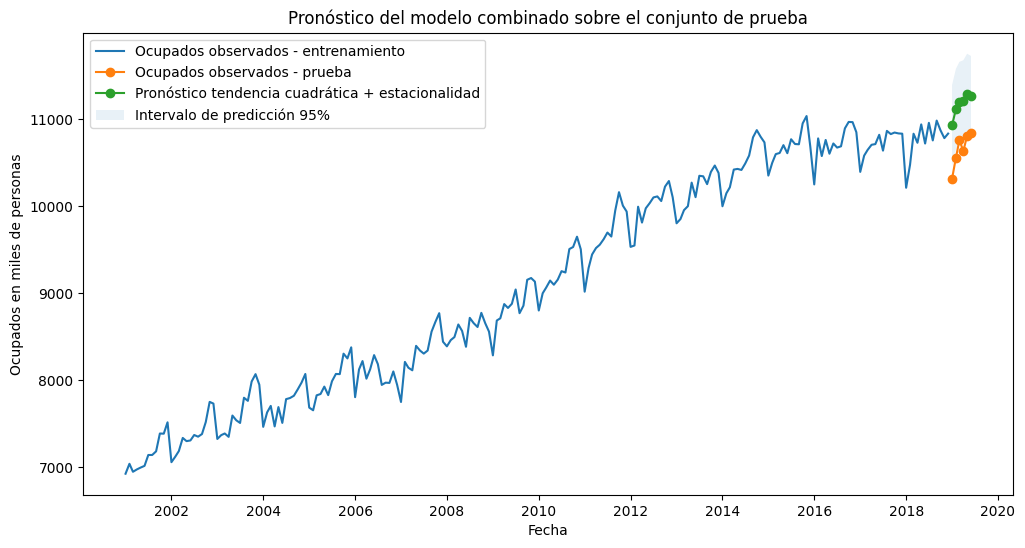

In [ ]:
# Se grafica la serie de entrenamiento, la serie de prueba y el pronóstico combinado.
plt.figure(figsize=(12, 6))

plt.plot(train, label="Ocupados observados - entrenamiento")
plt.plot(test, label="Ocupados observados - prueba", marker="o")
plt.plot(
    preds_comb_test["Point_forecast"],
    label="Pronóstico tendencia cuadrática + estacionalidad",
    marker="o"
)

# Se agrega el intervalo de predicción al 95%.
plt.fill_between(
    preds_comb_test.index,
    preds_comb_test["lower_95"],
    preds_comb_test["upper_95"],
    alpha=0.1,
    label="Intervalo de predicción 95%"
)

plt.title("Pronóstico del modelo combinado sobre el conjunto de prueba")
plt.xlabel("Fecha")
plt.ylabel("Ocupados en miles de personas")
plt.legend()
plt.grid()

plt.show()

**Pronóstico del modelo combinado sobre el conjunto de prueba**

La gráfica muestra que el modelo de tendencia cuadrática más estacionalidad mensual genera pronósticos más cercanos al conjunto de prueba que los modelos anteriores, especialmente frente al modelo puramente estacional, que subestimaba de manera importante los valores recientes. Los pronósticos del modelo combinado siguen una trayectoria creciente y se ubican en niveles similares a los observados en 2019. Sin embargo, todavía se aprecia una leve sobreestimación, ya que los valores pronosticados se encuentran por encima de varios datos reales del conjunto de prueba. A pesar de ello, las observaciones reales se mantienen dentro del intervalo de predicción al **95%**, lo que indica que el modelo captura razonablemente la incertidumbre del periodo evaluado. La decisión final dependerá del **RMSE** y de la evaluación formal de los supuestos de los residuos.

In [ ]:
# Se calcula el RMSE comparando los valores reales de prueba
# contra los pronósticos puntuales del modelo combinado.
rmse_comb = np.sqrt(mean_squared_error(test, preds_comb_test["Point_forecast"]))

print("RMSE del modelo combinado:", round(rmse_comb, 4))

RMSE del modelo combinado: 519.2259


**Evaluación del error del modelo combinado**

El desempeño predictivo del modelo de tendencia cuadrática más estacionalidad mensual se evaluó comparando los valores reales del conjunto de prueba con los pronósticos puntuales generados para los seis primeros meses de 2019. El **RMSE obtenido fue de 519,2259**, lo que representa el menor error entre los modelos evaluados hasta este punto. Este resultado muestra una mejora frente al modelo de tendencia lineal, cuyo RMSE fue **725,5285**, frente al modelo de tendencia cuadrática, con **632,4767**, y frente al modelo de estacionalidad mensual, con **1.685,7662**. Por tanto, la combinación de tendencia y estacionalidad mejora la capacidad predictiva sobre el conjunto de prueba. Sin embargo, antes de seleccionarlo como modelo final, será necesario revisar formalmente los supuestos de los residuos, especialmente autocorrelación, homoscedasticidad y normalidad.

# **8. Comparación de modelos**

En esta sección se comparan los modelos estimados utilizando el **RMSE** como métrica de desempeño fuera de muestra. La comparación se realiza sobre el conjunto de prueba, conformado por las últimas seis observaciones disponibles de la serie **Ocupados**. Esta estrategia permite evaluar qué tan bien pronostica cada modelo datos que no fueron utilizados durante su estimación. Posteriormente, esta comparación se complementará con la evaluación de los supuestos de los residuos, con el fin de seleccionar el modelo más adecuado no solo por su error de pronóstico, sino también por la calidad estadística de sus residuos.

In [ ]:
# Se construye una tabla con los modelos estimados y su respectivo RMSE
# calculado sobre el conjunto de prueba.

tabla_rmse = pd.DataFrame({
    "Modelo": [
        "Tendencia lineal",
        "Tendencia cuadrática",
        "Estacionalidad mensual",
        "Tendencia cuadrática + estacionalidad mensual"
    ],
    "RMSE": [
        rmse_lineal,
        rmse_cuadratico,
        rmse_estacional,
        rmse_comb
    ]
})

# Se redondea el RMSE para facilitar la lectura.
tabla_rmse["RMSE"] = tabla_rmse["RMSE"].round(4)

# Se ordenan los modelos de menor a mayor RMSE.
tabla_rmse = tabla_rmse.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

# Se visualiza la tabla comparativa.
tabla_rmse

,Modelo,RMSE
0,Tendencia cuadrática + estacionalidad mensual,519.2259
1,Tendencia cuadrática,632.4767
2,Tendencia lineal,725.5285
3,Estacionalidad mensual,"1,685.7662"


**Comparación de modelos según RMSE**

La comparación fuera de muestra muestra que el modelo de **tendencia cuadrática más estacionalidad mensual** presenta el menor **RMSE**, con un valor de **519,2259**, por lo que ofrece el mejor desempeño predictivo sobre el conjunto de prueba. En segundo lugar se ubica el modelo de **tendencia cuadrática**, con un RMSE de **632,4767**, seguido por el modelo de **tendencia lineal**, con **725,5285**. El modelo de **estacionalidad mensual** presenta el mayor error, con un RMSE de **1.685,7662**, lo que confirma que la estacionalidad por sí sola no logra capturar la tendencia creciente de la serie **Ocupados**. En consecuencia, desde la perspectiva del error de pronóstico, el modelo combinado se perfila como el mejor candidato preliminar; sin embargo, la decisión final debe complementarse con la evaluación de los supuestos de los residuos.

# **9. Evaluación de los supuestos de los residuos**

Para seleccionar el mejor modelo no basta con revisar el **RMSE**. También se deben evaluar los supuestos sobre los residuos, dado que un buen modelo de pronóstico debería dejar errores sin patrones sistemáticos. En esta sección se revisan tres aspectos para cada modelo estimado: **autocorrelación**, **homoscedasticidad** y **normalidad** de los residuos.

## **9.1 Autocorrelación de los residuos**

La autocorrelación permite evaluar si los residuos de un modelo presentan dependencia temporal. En un modelo adecuado, se espera que los residuos no conserven patrones sistemáticos asociados al tiempo. Para esta evaluación se aplican las pruebas de **Ljung-Box** y **Box-Pierce** sobre los primeros 20 rezagos, utilizando un nivel de significancia del **5%**.

La hipótesis nula de estas pruebas plantea que no existe autocorrelación en los residuos. Por tanto, si el p-valor es menor que **0,05**, se concluye que hay evidencia de autocorrelación. En cambio, si el p-valor es mayor o igual a **0,05**, no se encuentra evidencia suficiente de autocorrelación.

In [ ]:
# Se define una función para aplicar las pruebas Ljung-Box y Box-Pierce
# sobre los residuos de cada modelo estimado.

def evaluar_autocorrelacion(nombre_modelo, residuos, lags=20, alpha=0.05):

    # Se convierten los residuos en una serie de pandas y se eliminan valores faltantes.
    residuos = pd.Series(residuos).dropna()

    # Se aplican las pruebas Ljung-Box y Box-Pierce para los rezagos definidos.
    prueba_autocorrelacion = sm.stats.acorr_ljungbox(
        residuos,
        lags=range(1, lags + 1),
        return_df=True,
        boxpierce=True
    )

    # Se identifica el menor p-valor de la prueba Ljung-Box.
    p_min_ljung_box = prueba_autocorrelacion["lb_pvalue"].min()

    # Se identifica el menor p-valor de la prueba Box-Pierce.
    p_min_box_pierce = prueba_autocorrelacion["bp_pvalue"].min()

    # Se toma la decisión con base en el nivel de significancia.
    # Si algún p-valor es menor que 0.05, hay evidencia de autocorrelación.
    if (p_min_ljung_box < alpha) or (p_min_box_pierce < alpha):
        diagnostico = "Con evidencia de autocorrelación"
    else:
        diagnostico = "Sin evidencia de autocorrelación"

    # Se devuelve un resumen con los resultados principales.
    return {
        "Modelo": nombre_modelo,
        "p_min_Ljung_Box": p_min_ljung_box,
        "p_min_Box_Pierce": p_min_box_pierce,
        "Diagnóstico autocorrelación": diagnostico
    }

In [ ]:
# Se crea una lista vacía para almacenar los resultados.
resultados_autocorrelacion = []

# Se evalúan los residuos del modelo de tendencia lineal.
resultados_autocorrelacion.append(
    evaluar_autocorrelacion(
        nombre_modelo="Tendencia lineal",
        residuos=lineal_resid,
        lags=20,
        alpha=0.05
    )
)

# Se evalúan los residuos del modelo de tendencia cuadrática.
resultados_autocorrelacion.append(
    evaluar_autocorrelacion(
        nombre_modelo="Tendencia cuadrática",
        residuos=cuadratico_resid,
        lags=20,
        alpha=0.05
    )
)

# Se evalúan los residuos del modelo de estacionalidad mensual.
resultados_autocorrelacion.append(
    evaluar_autocorrelacion(
        nombre_modelo="Estacionalidad mensual",
        residuos=estacional_resid,
        lags=20,
        alpha=0.05
    )
)

# Se evalúan los residuos del modelo combinado.
resultados_autocorrelacion.append(
    evaluar_autocorrelacion(
        nombre_modelo="Tendencia cuadrática + estacionalidad mensual",
        residuos=comb_resid,
        lags=20,
        alpha=0.05
    )
)

# Se construye una tabla con los resultados.
tabla_autocorrelacion = pd.DataFrame(resultados_autocorrelacion)

# Se redondean los p-valores para facilitar la lectura.
tabla_autocorrelacion["p_min_Ljung_Box"] = tabla_autocorrelacion["p_min_Ljung_Box"].round(4)
tabla_autocorrelacion["p_min_Box_Pierce"] = tabla_autocorrelacion["p_min_Box_Pierce"].round(4)

# Se visualiza la tabla de resultados.
tabla_autocorrelacion

,Modelo,p_min_Ljung_Box,p_min_Box_Pierce,Autocorrelación
0,Tendencia lineal,0.0000,0.0000,No cumple
1,Tendencia cuadrática,0.0000,0.0000,No cumple
2,Estacionalidad mensual,0.0000,0.0000,No cumple
3,Tendencia cuadrática + estacionalidad mensual,0.0000,0.0000,No cumple


**Evaluación de autocorrelación de los residuos**

Los resultados de las pruebas de **Ljung-Box** y **Box-Pierce** muestran p-valores mínimos iguales a **0,0000** para todos los modelos evaluados. Dado que estos valores son menores al nivel de significancia del **5%**, se rechaza la hipótesis nula de ausencia de autocorrelación. Por tanto, existe evidencia estadística de **autocorrelación en los residuos** de todos los modelos. Esto significa que, aunque algunos modelos presentan menor error de pronóstico, especialmente el modelo de **tendencia cuadrática más estacionalidad mensual**, ninguno logra eliminar completamente la dependencia temporal en los errores. En consecuencia, los modelos evaluados no satisfacen plenamente el supuesto de independencia de los residuos.

## **9.2 Homoscedasticidad de los residuos**

La homoscedasticidad implica que la varianza de los residuos se mantiene aproximadamente constante en el tiempo. Para evaluar este supuesto, se aplica la prueba de **Ljung-Box** sobre los residuos al cuadrado. Si los residuos al cuadrado presentan autocorrelación significativa, se interpreta como evidencia de heteroscedasticidad o de posible comportamiento tipo ARCH/GARCH.

La hipótesis nula plantea que no existe autocorrelación en los residuos al cuadrado, lo cual es consistente con varianza constante. Por tanto, si el p-valor es menor que **0,05**, se concluye que hay evidencia de heteroscedasticidad. Si el p-valor es mayor o igual a **0,05**, no se encuentra evidencia suficiente de heteroscedasticidad.

In [ ]:
# Se define una función para aplicar la prueba Ljung-Box
# sobre los residuos al cuadrado de cada modelo estimado.

def evaluar_homoscedasticidad(nombre_modelo, residuos, lags=20, alpha=0.05):

    # Se convierten los residuos en una serie de pandas y se eliminan valores faltantes.
    residuos = pd.Series(residuos).dropna()

    # Se calculan los residuos al cuadrado.
    residuos_cuadrado = residuos ** 2

    # Se aplica la prueba Ljung-Box sobre los residuos al cuadrado.
    prueba_homoscedasticidad = sm.stats.acorr_ljungbox(
        residuos_cuadrado,
        lags=range(1, lags + 1),
        return_df=True,
        boxpierce=True
    )

    # Se identifica el menor p-valor de la prueba Ljung-Box.
    p_min_ljung_box_cuadrado = prueba_homoscedasticidad["lb_pvalue"].min()

    # Se identifica el menor p-valor de la prueba Box-Pierce.
    p_min_box_pierce_cuadrado = prueba_homoscedasticidad["bp_pvalue"].min()

    # Se toma la decisión con base en el nivel de significancia.
    # Si algún p-valor es menor que 0.05, hay evidencia de heteroscedasticidad.
    if (p_min_ljung_box_cuadrado < alpha) or (p_min_box_pierce_cuadrado < alpha):
        diagnostico = "Con evidencia de heteroscedasticidad"
    else:
        diagnostico = "Sin evidencia de heteroscedasticidad"

    # Se devuelve un resumen con los resultados principales.
    return {
        "Modelo": nombre_modelo,
        "p_min_Ljung_Box_residuos_cuadrado": p_min_ljung_box_cuadrado,
        "p_min_Box_Pierce_residuos_cuadrado": p_min_box_pierce_cuadrado,
        "Diagnóstico homoscedasticidad": diagnostico
    }

In [ ]:
# ============================================================
# 9.2.1 Aplicación de pruebas de homoscedasticidad a los modelos
# ============================================================

# Se crea una lista vacía para almacenar los resultados.
resultados_homoscedasticidad = []

# Se evalúan los residuos del modelo de tendencia lineal.
resultados_homoscedasticidad.append(
    evaluar_homoscedasticidad(
        nombre_modelo="Tendencia lineal",
        residuos=lineal_resid,
        lags=20,
        alpha=0.05
    )
)

# Se evalúan los residuos del modelo de tendencia cuadrática.
resultados_homoscedasticidad.append(
    evaluar_homoscedasticidad(
        nombre_modelo="Tendencia cuadrática",
        residuos=cuadratico_resid,
        lags=20,
        alpha=0.05
    )
)

# Se evalúan los residuos del modelo de estacionalidad mensual.
resultados_homoscedasticidad.append(
    evaluar_homoscedasticidad(
        nombre_modelo="Estacionalidad mensual",
        residuos=estacional_resid,
        lags=20,
        alpha=0.05
    )
)

# Se evalúan los residuos del modelo combinado.
resultados_homoscedasticidad.append(
    evaluar_homoscedasticidad(
        nombre_modelo="Tendencia cuadrática + estacionalidad mensual",
        residuos=comb_resid,
        lags=20,
        alpha=0.05
    )
)

# Se construye una tabla con los resultados.
tabla_homoscedasticidad = pd.DataFrame(resultados_homoscedasticidad)

# Se redondean los p-valores para facilitar la lectura.
tabla_homoscedasticidad["p_min_Ljung_Box_residuos_cuadrado"] = tabla_homoscedasticidad["p_min_Ljung_Box_residuos_cuadrado"].round(4)
tabla_homoscedasticidad["p_min_Box_Pierce_residuos_cuadrado"] = tabla_homoscedasticidad["p_min_Box_Pierce_residuos_cuadrado"].round(4)

# Se visualiza la tabla de resultados.
tabla_homoscedasticidad

,Modelo,p_min_Ljung_Box_residuos_cuadrado,p_min_Box_Pierce_residuos_cuadrado,Diagnóstico homoscedasticidad
0,Tendencia lineal,0.0000,0.0000,Con evidencia de heteroscedasticidad
1,Tendencia cuadrática,0.0000,0.0000,Con evidencia de heteroscedasticidad
2,Estacionalidad mensual,0.0000,0.0000,Con evidencia de heteroscedasticidad
3,Tendencia cuadrática + estacionalidad mensual,0.0000,0.0000,Con evidencia de heteroscedasticidad


**Evaluación de homoscedasticidad de los residuos**

Los resultados de la prueba de **Ljung-Box** y **Box-Pierce** aplicada sobre los residuos al cuadrado muestran p-valores mínimos iguales a **0,0000** para todos los modelos evaluados. Dado que estos valores son menores al nivel de significancia del **5%**, se encuentra evidencia estadística de **heteroscedasticidad** en los residuos. Esto significa que la variabilidad de los errores no parece mantenerse constante en el tiempo y que pueden existir periodos con mayor o menor dispersión residual. En consecuencia, aunque el modelo de **tendencia cuadrática más estacionalidad mensual** presenta el menor RMSE, sus residuos aún muestran señales de varianza no constante. Esta limitación deberá mencionarse en el informe final, especialmente porque afecta la interpretación estadística del modelo y la confiabilidad de los intervalos de predicción.

## **9.3 Normalidad de los residuos**

La normalidad de los residuos permite evaluar si los errores del modelo se distribuyen de manera aproximadamente normal. Para esta revisión se utilizan las pruebas de **Jarque-Bera** y **Shapiro-Wilk**, con un nivel de significancia del **5%**.

La hipótesis nula de ambas pruebas plantea que los residuos siguen una distribución normal. Por tanto, si el p-valor es menor que **0,05**, se rechaza la normalidad. Si el p-valor es mayor o igual a **0,05**, no se encuentra evidencia suficiente para rechazarla.

In [ ]:
# Se define una función para aplicar las pruebas de normalidad
# Jarque-Bera y Shapiro-Wilk sobre los residuos de cada modelo.

def evaluar_normalidad(nombre_modelo, residuos, alpha=0.05):

    # Se convierten los residuos en una serie de pandas y se eliminan valores faltantes.
    residuos = pd.Series(residuos).dropna()

    # Se aplica la prueba de Jarque-Bera.
    jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(residuos)

    # Se aplica la prueba de Shapiro-Wilk.
    shapiro_stat, shapiro_pvalue = stats.shapiro(residuos)

    # Se toma la decisión con base en el nivel de significancia.
    # Si algún p-valor es menor que 0.05, hay evidencia para rechazar normalidad.
    if (jb_pvalue < alpha) or (shapiro_pvalue < alpha):
        diagnostico = "Con evidencia de no normalidad"
    else:
        diagnostico = "Sin evidencia de no normalidad"

    # Se devuelve un resumen con los resultados principales.
    return {
        "Modelo": nombre_modelo,
        "p_Jarque_Bera": jb_pvalue,
        "p_Shapiro_Wilk": shapiro_pvalue,
        "Diagnóstico normalidad": diagnostico
    }

In [ ]:
# Se crea una lista vacía para almacenar los resultados.
resultados_normalidad = []

# Se evalúan los residuos del modelo de tendencia lineal.
resultados_normalidad.append(
    evaluar_normalidad(
        nombre_modelo="Tendencia lineal",
        residuos=lineal_resid,
        alpha=0.05
    )
)

# Se evalúan los residuos del modelo de tendencia cuadrática.
resultados_normalidad.append(
    evaluar_normalidad(
        nombre_modelo="Tendencia cuadrática",
        residuos=cuadratico_resid,
        alpha=0.05
    )
)

# Se evalúan los residuos del modelo de estacionalidad mensual.
resultados_normalidad.append(
    evaluar_normalidad(
        nombre_modelo="Estacionalidad mensual",
        residuos=estacional_resid,
        alpha=0.05
    )
)

# Se evalúan los residuos del modelo combinado.
resultados_normalidad.append(
    evaluar_normalidad(
        nombre_modelo="Tendencia cuadrática + estacionalidad mensual",
        residuos=comb_resid,
        alpha=0.05
    )
)

# Se construye una tabla con los resultados.
tabla_normalidad = pd.DataFrame(resultados_normalidad)

# Se redondean los p-valores para facilitar la lectura.
tabla_normalidad["p_Jarque_Bera"] = tabla_normalidad["p_Jarque_Bera"].round(4)
tabla_normalidad["p_Shapiro_Wilk"] = tabla_normalidad["p_Shapiro_Wilk"].round(4)

# Se visualiza la tabla de resultados.
tabla_normalidad

,Modelo,p_Jarque_Bera,p_Shapiro_Wilk,Diagnóstico normalidad
0,Tendencia lineal,0.7839,0.4902,Sin evidencia de no normalidad
1,Tendencia cuadrática,0.7524,0.4790,Sin evidencia de no normalidad
2,Estacionalidad mensual,0.0000,0.0000,Con evidencia de no normalidad
3,Tendencia cuadrática + estacionalidad mensual,0.0604,0.0078,Con evidencia de no normalidad


**Evaluación de normalidad de los residuos**

Los resultados de las pruebas de **Jarque-Bera** y **Shapiro-Wilk** muestran comportamientos distintos entre los modelos evaluados. En los modelos de **tendencia lineal** y **tendencia cuadrática**, los p-valores son mayores al nivel de significancia del **5%**, por lo que no se encuentra evidencia suficiente para rechazar la normalidad de los residuos. En cambio, el modelo de **estacionalidad mensual** presenta p-valores iguales a **0,0000**, lo que indica evidencia de no normalidad. Para el modelo de **tendencia cuadrática más estacionalidad mensual**, el resultado es mixto: la prueba de **Jarque-Bera** presenta un p-valor de **0,0604**, ligeramente superior a 0,05, mientras que **Shapiro-Wilk** presenta un p-valor de **0,0078**, menor a 0,05. Por tanto, se considera que este modelo presenta evidencia de no normalidad según Shapiro-Wilk, aunque no de manera contundente en ambas pruebas. Esta limitación debe tenerse en cuenta en la selección final del modelo, especialmente al interpretar intervalos y pruebas estadísticas.

In [ ]:
# ============================================================
# 10. Tabla consolidada de modelos, RMSE y supuestos
# ============================================================

# Se parte de la tabla de RMSE ya construida previamente.
tabla_final = tabla_rmse.copy()

# ------------------------------------------------------------
# Se ajusta la tabla de autocorrelación para dejar un diagnóstico claro.
# Si la tabla tiene la columna "Autocorrelación" con "No cumple",
# se traduce a una frase explícita.
# ------------------------------------------------------------

tabla_auto_resumen = tabla_autocorrelacion.copy()

if "Autocorrelación" in tabla_auto_resumen.columns:
    tabla_auto_resumen["Diagnóstico autocorrelación"] = tabla_auto_resumen["Autocorrelación"].replace({
        "No cumple": "Con evidencia de autocorrelación",
        "Cumple": "Sin evidencia de autocorrelación"
    })

tabla_auto_resumen = tabla_auto_resumen[
    [
        "Modelo",
        "p_min_Ljung_Box",
        "p_min_Box_Pierce",
        "Diagnóstico autocorrelación"
    ]
]

# ------------------------------------------------------------
# Se prepara la tabla de homoscedasticidad.
# ------------------------------------------------------------

tabla_homo_resumen = tabla_homoscedasticidad[
    [
        "Modelo",
        "p_min_Ljung_Box_residuos_cuadrado",
        "p_min_Box_Pierce_residuos_cuadrado",
        "Diagnóstico homoscedasticidad"
    ]
].copy()

# ------------------------------------------------------------
# Se prepara la tabla de normalidad.
# ------------------------------------------------------------

tabla_norm_resumen = tabla_normalidad[
    [
        "Modelo",
        "p_Jarque_Bera",
        "p_Shapiro_Wilk",
        "Diagnóstico normalidad"
    ]
].copy()

# ------------------------------------------------------------
# Se integran todas las tablas.
# ------------------------------------------------------------

tabla_final = tabla_final.merge(
    tabla_auto_resumen,
    on="Modelo",
    how="left"
)

tabla_final = tabla_final.merge(
    tabla_homo_resumen,
    on="Modelo",
    how="left"
)

tabla_final = tabla_final.merge(
    tabla_norm_resumen,
    on="Modelo",
    how="left"
)

# ------------------------------------------------------------
# Se redondean los p-valores y el RMSE.
# ------------------------------------------------------------

columnas_redondear = [
    "RMSE",
    "p_min_Ljung_Box",
    "p_min_Box_Pierce",
    "p_min_Ljung_Box_residuos_cuadrado",
    "p_min_Box_Pierce_residuos_cuadrado",
    "p_Jarque_Bera",
    "p_Shapiro_Wilk"
]

for columna in columnas_redondear:
    if columna in tabla_final.columns:
        tabla_final[columna] = tabla_final[columna].round(4)

# ------------------------------------------------------------
# Se agrega una decisión preliminar con base en RMSE y supuestos.
# ------------------------------------------------------------

menor_rmse = tabla_final["RMSE"].min()

tabla_final["Decisión"] = np.where(
    tabla_final["RMSE"] == menor_rmse,
    "Mejor RMSE; candidato principal con limitaciones en supuestos",
    "No seleccionado frente al menor RMSE"
)

# Se ordena la tabla de menor a mayor RMSE.
tabla_final = tabla_final.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

# Se visualiza la tabla consolidada.
tabla_final

,Modelo,RMSE,p_min_Ljung_Box,p_min_Box_Pierce,Diagnóstico autocorrelación,p_min_Ljung_Box_residuos_cuadrado,p_min_Box_Pierce_residuos_cuadrado,Diagnóstico homoscedasticidad,p_Jarque_Bera,p_Shapiro_Wilk,Diagnóstico normalidad,Decisión
0,Tendencia cuadrática + estacionalidad mensual,519.2259,0.0000,0.0000,Con evidencia de autocorrelación,0.0000,0.0000,Con evidencia de heteroscedasticidad,0.0604,0.0078,Con evidencia de no normalidad,Mejor RMSE; candidato principal con limitacion...
1,Tendencia cuadrática,632.4767,0.0000,0.0000,Con evidencia de autocorrelación,0.0000,0.0000,Con evidencia de heteroscedasticidad,0.7524,0.4790,Sin evidencia de no normalidad,No seleccionado frente al menor RMSE
2,Tendencia lineal,725.5285,0.0000,0.0000,Con evidencia de autocorrelación,0.0000,0.0000,Con evidencia de heteroscedasticidad,0.7839,0.4902,Sin evidencia de no normalidad,No seleccionado frente al menor RMSE
3,Estacionalidad mensual,"1,685.7662",0.0000,0.0000,Con evidencia de autocorrelación,0.0000,0.0000,Con evidencia de heteroscedasticidad,0.0000,0.0000,Con evidencia de no normalidad,No seleccionado frente al menor RMSE


**Tabla consolidada de comparación de modelos**

La tabla consolidada permite comparar los modelos estimados considerando dos criterios: el desempeño predictivo, medido mediante el **RMSE** en el conjunto de prueba, y el comportamiento estadístico de los residuos. El modelo de **tendencia cuadrática más estacionalidad mensual** presenta el menor RMSE, con un valor de **519,2259**, por lo que se identifica como el mejor candidato desde el punto de vista del error de pronóstico. Sin embargo, las pruebas de residuos muestran que todos los modelos presentan evidencia de **autocorrelación** y **heteroscedasticidad**, lo cual indica que aún quedan patrones temporales y variabilidad no constante en los errores. En cuanto a la normalidad, los modelos de tendencia lineal y cuadrática no presentan evidencia de no normalidad, mientras que el modelo estacional y el modelo combinado sí muestran señales de incumplimiento de este supuesto. En consecuencia, el modelo combinado se selecciona como la mejor alternativa entre las evaluadas por su menor error fuera de muestra, pero su uso debe acompañarse de una advertencia sobre las limitaciones observadas en los supuestos de los residuos.

### **12. Ejercicio en Clase**

Empleando la información del número de ocupados en miles de personas (Ocupados) para las 13 principales ciudades, encuentre el mejor pronóstico para los próximos 6 meses empleando los métodos vistos en la clase. Compare los resultados con el mejor modelo encontrado en el ejercicio anterior.Escriba un breve informe de máximo una página de texto que explique cómo llega a sus proyeccciones y presente las proyecciones. Aclare en el texto cuáles serían las limitaciones de sus pronósticos.